# Task 1: # Full Analytical Report – IRA Troll Factory Tweets (PySpark)

**Course:** Big Data and Smart Data Analytics

**Assignment:** Analyze 3 million tweets produced by the IRA troll factory in the 2012-2018 period - Advanced Data Analysis and Full Analytical Report

**Students:** Bastien Goiffon , Priscille Montoussé , Sara Silva

**Date:** 10/12/2025

## 1. Introduction to the notebook

We explore and analyse the merged dataset of ~3 million tweets (2012–2018) associated with accounts linked to the Internet Research Agency, using PySpark on Microsoft Fabric. As in the data-cleaning notebook, this EDA and analysis operates on the merged CSV built from the 13 files published by FiveThirtyEight.

**This notebook covers:**

- Loading & quick inspection of the analysis dataset (schema, row counts, basic sanity checks).

- Time series views: monthly activity, weekly/weekday patterns, and hour-of-day distributions.

- Audience targeting: volumes by language and region, with top-k breakdowns.

- Amplification behavior: share of retweets vs original posts over time (and by key categories).

- Narratives: extraction of hashtags and identification of the most popular hashtag per month.

- Accounts & reach proxies: activity by account, “only-repost” accounts, and a simple check of posting vs followers.

- Compact visualizations accompanying each section (line charts for time series, stacked bars for composition, and tables/charts for hashtag leaders).

**Our process:**

- Reuse the variable definitions from the data-cleaning work (e.g., publish_date, language, post_type, retweet, followers, account_category) and ensure consistent types for time and numeric fields.

- Derive analysis keys (e.g., month yyyy-MM, day of week, hour (UTC)) to support grouping and comparisons.

- Apply lightweight text normalization for hashtag extraction (e.g., keep # + alphanumeric/underscore; drop lone #).

- Report both counts and percentages where appropriate, and clearly state any assumptions (e.g., whether QUOTE_TWEET is treated as a repost).

- Save small aggregate tables (Delta/Parquet) for reproducibility and downstream visualization (e.g., Power BI).

**Deliverables:**

- A set of readable figures (monthly volume, % retweets, language/region mixes, hourly activity, monthly hashtag winners).

- Short takeaways below each figure, and a final executive summary highlighting key patterns (spikes, narrative shifts, amplification changes, and any relation between posting and followers).


## 2. Setup and Data Loading

In this section we configure the Spark session and import the PySpark functions used throughout the notebook. Some functions only useful for specific parts of the analysis will be imported in it. We also load our merged dataset _Cleaned IRA datatset.parket_ and, to confirm that the CSV has been appropriately parsed, we examine the schema and display 5 example rows.

In [92]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pyspark.sql.window import Window
from pyspark.sql import functions as F
from pyspark.ml.clustering import KMeans
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.feature import CountVectorizer, RegexTokenizer
from pyspark.ml.clustering import LDA
from pyspark.sql.types import IntegerType
from pyspark.sql.functions import udf
from pyspark.sql.functions import corr
from pyspark.sql.functions import (
    to_date, year, month, dayofweek, hour, count, desc
)
from pyspark.sql.functions import (
    col, lower, regexp_replace, split, explode, size, desc
)
from pyspark.ml.feature import Tokenizer, StopWordsRemover
from scipy.stats import kruskal

#change for your own path
parquet_path = "Files/cleaned_parquet_single"

StatementMeta(, 0c55ff1a-6d27-440c-ab65-b084db287c55, 94, Finished, Available, Finished)

In [93]:
df = spark.read.parquet(parquet_path)

df.printSchema()
df.show(5, truncate=False)

StatementMeta(, 0c55ff1a-6d27-440c-ab65-b084db287c55, 95, Finished, Available, Finished)

root
 |-- external_author_id: string (nullable = true)
 |-- author: string (nullable = true)
 |-- content: string (nullable = true)
 |-- region: string (nullable = true)
 |-- language: string (nullable = true)
 |-- publish_date: timestamp (nullable = true)
 |-- harvested_date: timestamp (nullable = true)
 |-- following: integer (nullable = true)
 |-- followers: integer (nullable = true)
 |-- updates: integer (nullable = true)
 |-- account_type: string (nullable = true)
 |-- new_june_2018: integer (nullable = true)
 |-- alt_external_id: string (nullable = true)
 |-- tweet_id: long (nullable = true)
 |-- article_url: string (nullable = true)
 |-- retweet: integer (nullable = true)
 |-- account_category: string (nullable = true)
 |-- n_links: integer (nullable = true)

+------------------+---------------+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

## 3.  Basic Dataset Overview

**In this part, we try to have a better understanding of the IRA dataset in general in order to perform deeper analysis in a second time.**

Before performing our analysis, we make sure that our dataset countains the right amount of rows and variables (columns) as defined during the dataset cleaning. 

In [94]:
# Number of rows and columns (variables)
n_rows = df.count()
n_cols = len(df.columns)

print(f"Total tweets: {n_rows}")
print(f"Total variables: {n_cols}")

print("\nColumns:")
for c in df.columns:
    print(" -", c)

StatementMeta(, 0c55ff1a-6d27-440c-ab65-b084db287c55, 96, Finished, Available, Finished)

Total tweets: 2944815
Total variables: 18

Columns:
 - external_author_id
 - author
 - content
 - region
 - language
 - publish_date
 - harvested_date
 - following
 - followers
 - updates
 - account_type
 - new_june_2018
 - alt_external_id
 - tweet_id
 - article_url
 - retweet
 - account_category
 - n_links


We computed **descriptive statistics** (number, mean, standard deviation, minimum and maximum) of certain variables like the number of followers or the percentage of retweets.

In [95]:
#Descriptive Statistics
num_cols = ["followers", "following", "updates", "new_june_2018", "retweet", "n_links"]

df.select(num_cols).describe().show()

StatementMeta(, 0c55ff1a-6d27-440c-ab65-b084db287c55, 97, Finished, Available, Finished)

+-------+------------------+------------------+-----------------+-------------------+------------------+------------------+
|summary|         followers|         following|          updates|      new_june_2018|           retweet|           n_links|
+-------+------------------+------------------+-----------------+-------------------+------------------+------------------+
|  count|           2944812|           2944812|          2944812|            2944815|           2944815|           2944815|
|   mean| 7058.570700268811|3450.3406940748678|10517.21350938532|0.44063277319627886|0.2094318318807803|0.9594769111132618|
| stddev|14638.600883633071| 5626.468347123373|17709.35373084861|0.49646310646392133|0.4069031775498423|0.7363545574134527|
|    min|                 0|                 0|                1|                  0|                 0|                 0|
|    max|            251276|             76210|           166113|                  1|                 1|                 3|
+-------

To have a better understanding about the dataset, it's necessary to know how the data is distributed, especially regarding the region, the language, the type and category of account. After computing it in a **table format**, we plot the data for each variable.

StatementMeta(, 0c55ff1a-6d27-440c-ab65-b084db287c55, 98, Finished, Available, Finished)


===== REGION =====


SynapseWidget(Synapse.DataFrame, b62f93a9-e086-4380-80d6-c087452098b1)

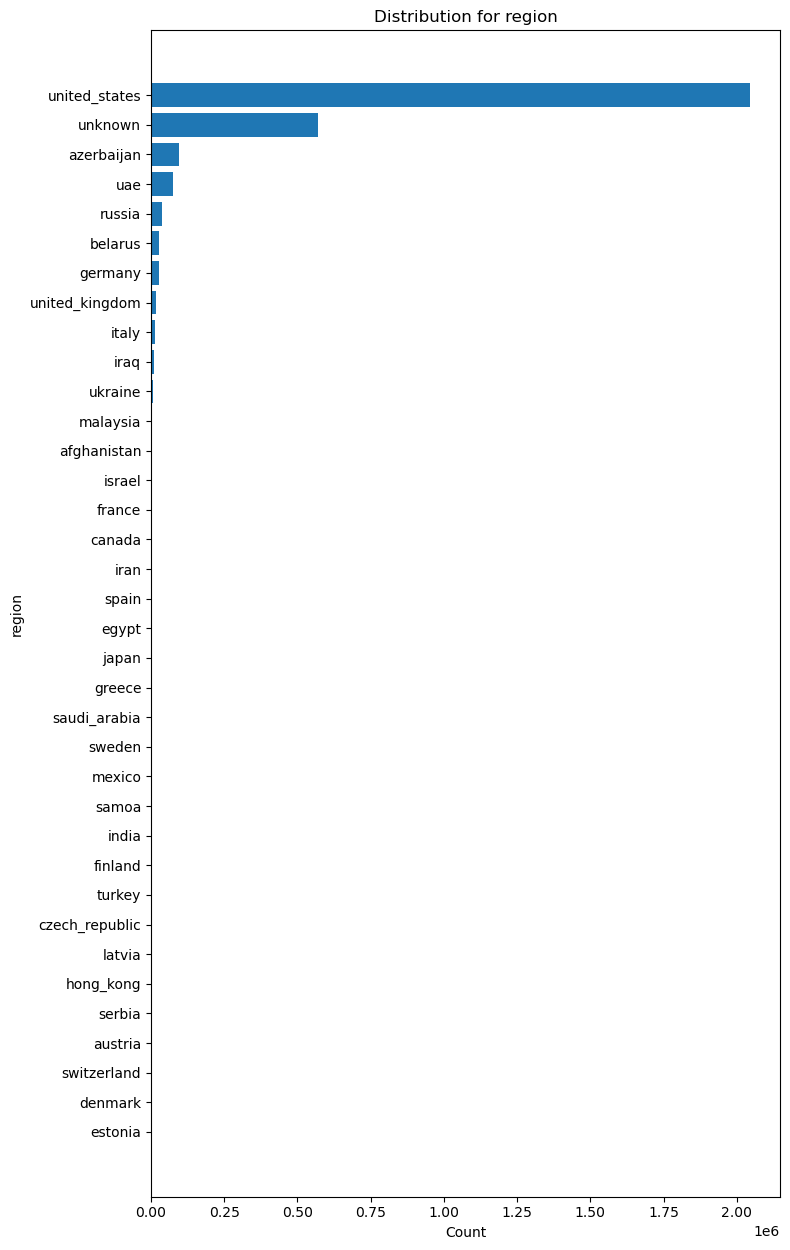


===== LANGUAGE =====


SynapseWidget(Synapse.DataFrame, 67b898bf-6123-4bc7-aff6-4bf108e40a37)

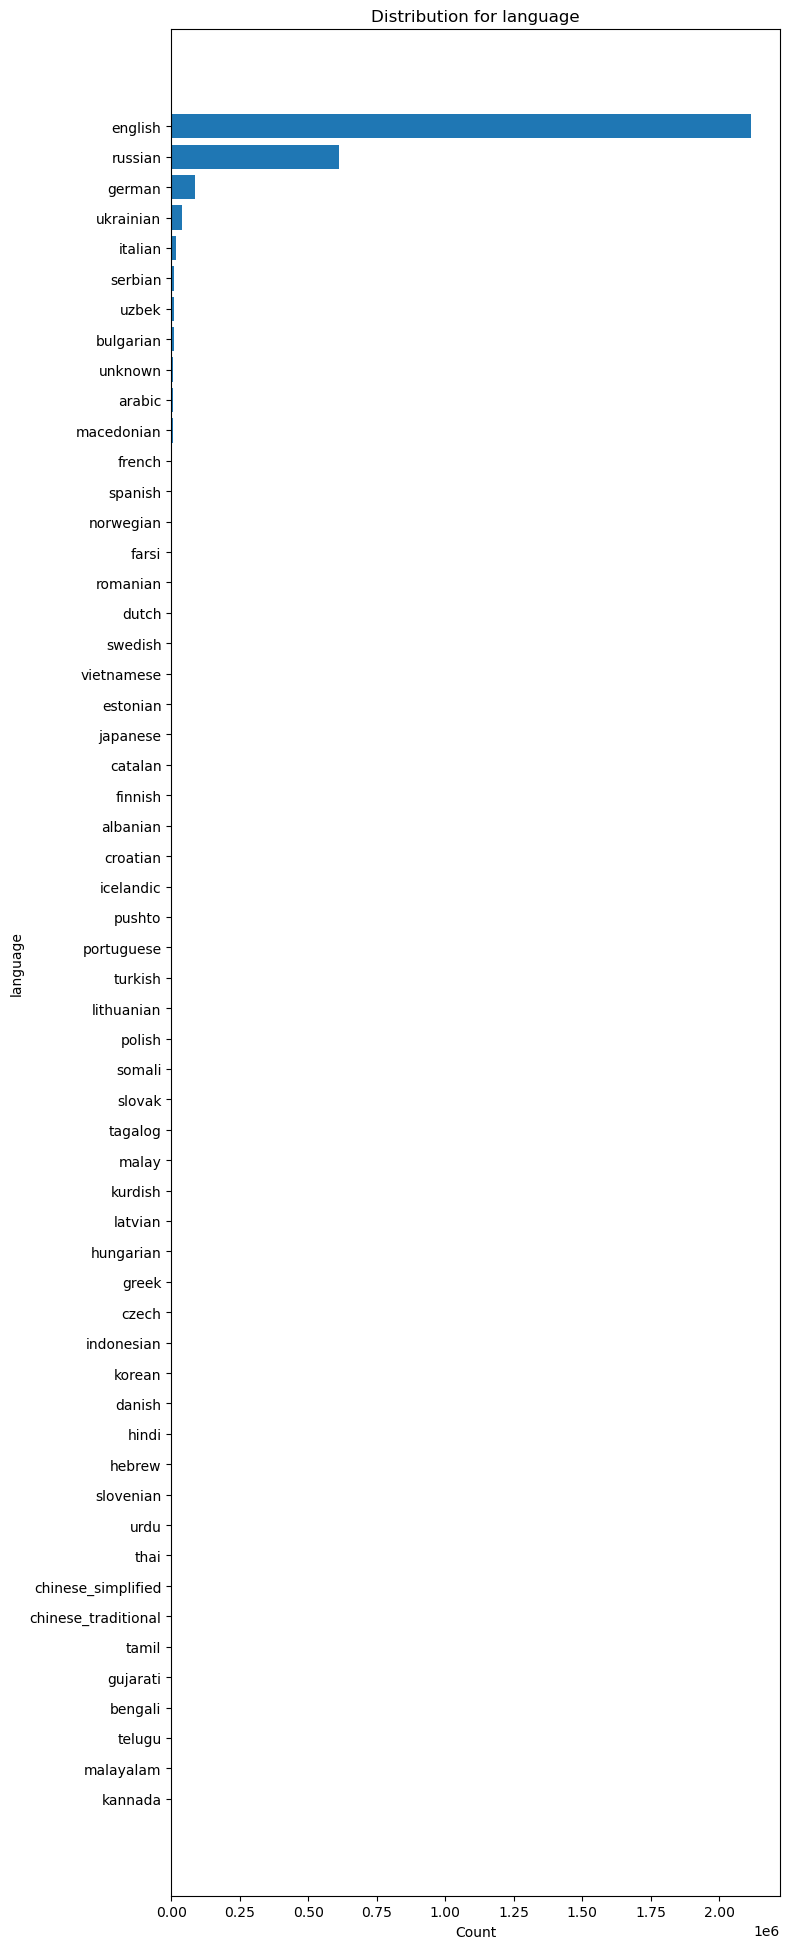


===== ACCOUNT_TYPE =====


SynapseWidget(Synapse.DataFrame, ffeb03ff-6923-4957-aead-8a0e3cddcb2b)

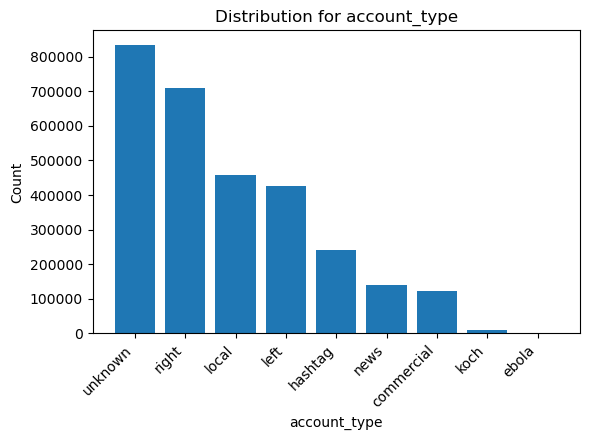


===== ACCOUNT_CATEGORY =====


SynapseWidget(Synapse.DataFrame, be8cc6dc-ffb1-420a-bbd4-ff73034e0a52)

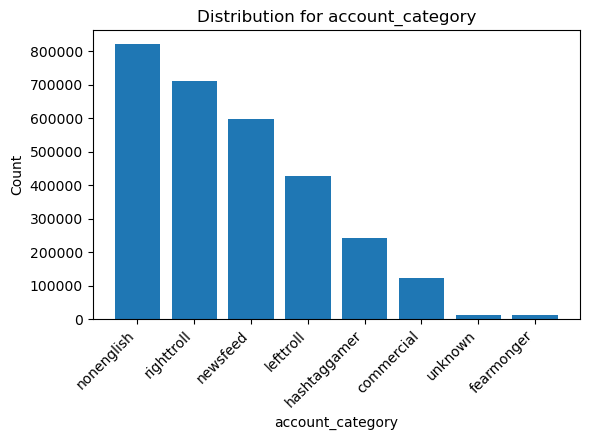

In [96]:
def plot_cat_dist(df, col, title=None):
    sdf = (df.groupBy(col)
             .count()
             .orderBy(F.col("count").desc()))
    
    pdf = sdf.toPandas()
    display(pdf)
    
    n = len(pdf)
    title = title or f"Distribution for {col}"
    if n <= 20:
        plt.figure(figsize=(max(6, n*0.6), 4.5))
        plt.bar(pdf[col].astype(str), pdf["count"])
        plt.title(title)
        plt.xlabel(col); plt.ylabel("Count")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()
    else:
        plt.figure(figsize=(8, max(6, n*0.35)))
        plt.barh(pdf[col].astype(str), pdf["count"])
        plt.title(title)
        plt.xlabel("Count"); plt.ylabel(col)
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.show()

cat_cols = ["region", "language", "account_type", "account_category"]

for c in cat_cols:
    print(f"\n===== {c.upper()} =====")
    plot_cat_dist(df, c)



As a result, 

**A- Distribution for region:**

1. United States: 2,045,317 tweets (~70%)

2. Unknown: 570,812

3. Azerbaijan: 96,333

4. UAE: 74,675

5. Russia: 37,589

The overwhelming majority of tweets were tagged with “united_states” as region. This supports the idea that IRA accounts pretend to be** American citizens**, especially from **politically active or marginalized communities**.

At the same time, most of non-US regions (Azerbaijan, UAE, Belarus) likely reflect:

- VPN routing

- Malformed metadata

- Misclassified geo-tags

- Attempts to mask origin


**B- Distribution for language:**
~72% of all content is in **English**, reflecting without a doubt the US-targeted mission.

**Russian-language tweets** appear mainly in early years of the dataset (2012–2014) and **“non-english” category** accounts helps IRA to spread local propaganda.

Multilingual activity (German, Italian, Arabic, Ukrainian) aligns with what can be considered as secondary European disinformation and align with refugee crisis narratives which takes place in Europe at that time, reflecting the far-right engagement.


**C- Distribution for account type and category:**

Without a surprise, the IRA operated **several types of personas**, each designed for different influence strategies:

- Right Trolls: patriotic, pro-Trump, anti-immigration messages

- Left Trolls: identity politics, racial justice angles

- Newsfeeds: appearing objective, amplifying divisive stories

- Hashtags: trend manipulation

- Local news: fake crises, shootings, community panic

The operation targeted both sides politically to maximize division, not to support only one ideology as well as trying to muddy the waters with commercial or newsfeeder account.


Here, we looked at the **20 top contributors**, meaning the accounts that post the more to analysis the behavior of such authors.

In [97]:
top_authors = (df.groupBy("author")
                 .count()
                 .orderBy(F.col("count").desc())
                 .withColumnRenamed("author", "Author")
                 .withColumnRenamed("count",  "Tweets"))
display(top_authors.limit(20))

StatementMeta(, 0c55ff1a-6d27-440c-ab65-b084db287c55, 99, Finished, Available, Finished)

SynapseWidget(Synapse.DataFrame, 6ff3a2ed-5acf-4591-8d24-20f65d296a4c)

After some researches, it appears that **these accounts are among the most well-documented IRA personas**. Moreover, the number of tweets are extreme, impossible for normal users even if the author and according to their account, pretend to be:

- US news outlets

- Political activists

- Lifestyle influencers

- Black community members

- Political commentators

As a tweeter dataset, the timeline analysis is particularly critical. Here we're only going to quickly look at the **number of tweets per year, per month and per day**. As the **time was standardize** during the data cleaning, this last analysis is possible. During a second time, we will focus more on the timeline to have deeper insights over the timeline.

StatementMeta(, 0c55ff1a-6d27-440c-ab65-b084db287c55, 100, Finished, Available, Finished)

Tweets per Year


SynapseWidget(Synapse.DataFrame, a3ef985a-7a6d-4f83-b28e-3a435dd55f98)

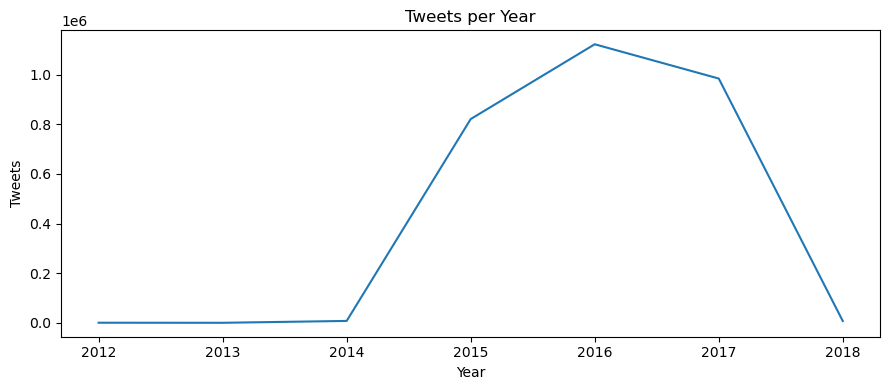

Tweets per Month


SynapseWidget(Synapse.DataFrame, 859201aa-f3be-4f9f-9339-12e118a74d3b)

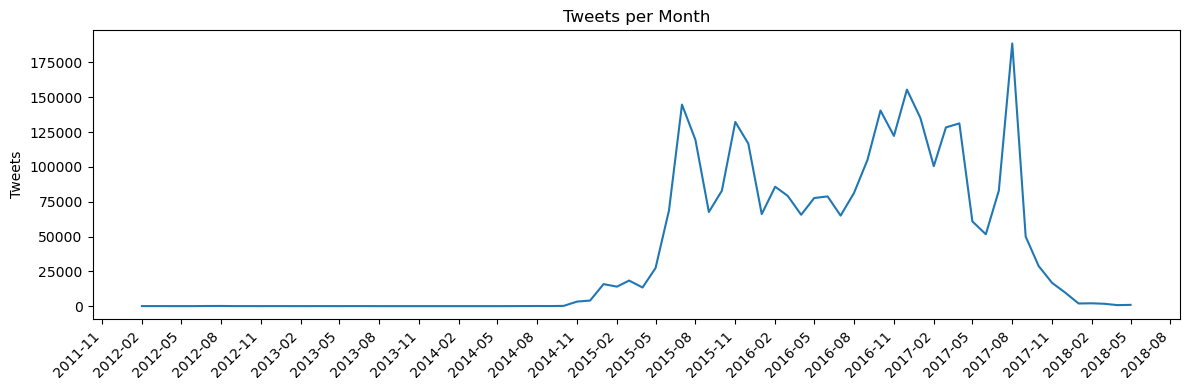

Tweets per Day


SynapseWidget(Synapse.DataFrame, 9924ee23-5504-4786-914a-8a8bf115a539)

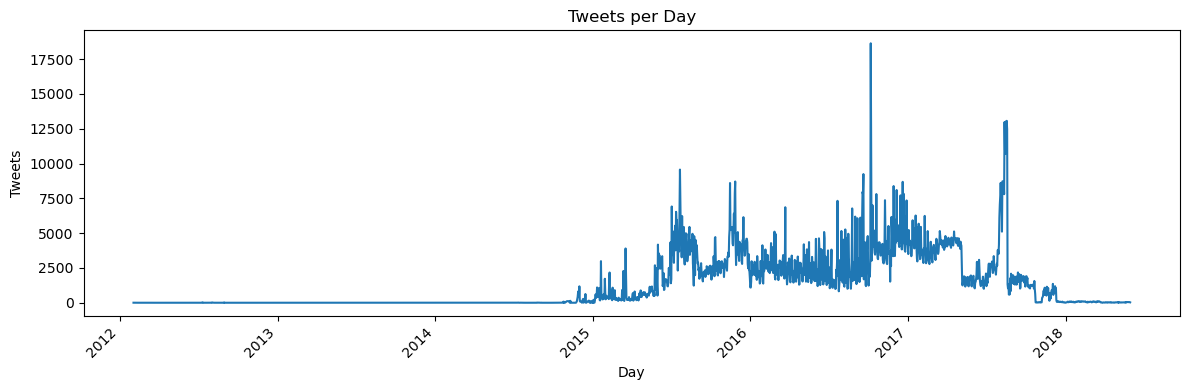

In [98]:
df_ts = (df
         .withColumn("publish_ts", F.to_timestamp("publish_date"))
         .filter(F.col("publish_ts").isNotNull()))

year_df = (df_ts
           .groupBy(F.year("publish_ts").alias("year"))
           .agg(F.count("*").alias("tweets"))
           .orderBy("year"))

month_df = (df_ts
            .groupBy(F.date_format("publish_ts", "yyyy-MM").alias("month"))
            .agg(F.count("*").alias("tweets"))
            .orderBy("month"))

day_df = (df_ts
          .groupBy(F.to_date("publish_ts").alias("day"))
          .agg(F.count("*").alias("tweets"))
          .orderBy("day"))

# Per year
print("Tweets per Year"); display(year_df)

pdf_year = year_df.toPandas().sort_values("year")
plt.figure(figsize=(9,4))
plt.plot(pdf_year["year"], pdf_year["tweets"])
plt.title("Tweets per Year")
plt.xlabel("Year"); plt.ylabel("Tweets")
plt.tight_layout(); plt.show()

# Per month
print("Tweets per Month"); display(month_df)

pdf_month = month_df.toPandas().sort_values("month")
pdf_month["month_dt"] = pd.to_datetime(pdf_month["month"] + "-01")
plt.figure(figsize=(12,4))
plt.plot(pdf_month["month_dt"], pdf_month["tweets"])
plt.title("Tweets per Month"); plt.ylabel("Tweets")
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45, ha="right")
plt.tight_layout(); plt.show()

# Per day
print("Tweets per Day"); display(day_df)

pdf_day = day_df.toPandas().sort_values("day")
plt.figure(figsize=(12,4))
plt.plot(pdf_day["day"], pdf_day["tweets"])
plt.title("Tweets per Day"); plt.xlabel("Day"); plt.ylabel("Tweets")
plt.xticks(rotation=45, ha="right")
plt.tight_layout(); plt.show()

It is clear with the year graph that, first, the IRA becomes operational at scale from 2015 onward. The year 2016 is the absolute peak which is directly aligned with the US Presidential Election.
Finally, the activity of these IRA accounts drops sharply in 2018 due to:

- Twitter shutdowns

- Public exposure

- Congressional investigation

On a more detailed scale, the month-by-month data also reveals specific spikes:

- **Late 2014 (Oct–Dec)** → ramp-up phase before the 2015 infiltration.

- **Mid–late 2015** → expansion, account creation, seeding narratives

- **2016 (Sep–Nov)** → highest activity, the election was indeed at the beginning of November

- **2017** → focus on division topics (race, police violence, immigration)

Another interesting part of a tweeter dataset is the retweet behavior. To do so, we stated by calculating the percentage of it.

In [99]:
total = df.count()
n_retweets = df.filter(F.col("retweet") == 1).count()
pct = round(n_retweets / total * 100, 2)

print(f"Retweets: {n_retweets} ({pct}%)")

StatementMeta(, 0c55ff1a-6d27-440c-ab65-b084db287c55, 101, Finished, Available, Finished)

Retweets: 616738 (20.94%)


Around 21% of the tweets are retweets. This is relatively low compared to the tweeter average (more than 25% according to Northwestern and Brown University). 

IRA accounts created **mostly original content**, unlike typical spam bots. A reasonable explanation is that the aim of IRA is not simply amplification but also narrative seeding. IRA accounts seem to behave “like humans”, by the generation of **unique posts**, not pure bot-like retweet streams.

Also, what is quite interesting in this dataset is the fact that the links published in a tweet are recorded. That is why to ease the analysis, we aggregated them on a single new variable that count the number of links from 0 to 3 "n_links"

In [100]:
base = df

total = base.count()

dist = (
    base.groupBy("n_links")
        .agg(F.count("*").alias("tweets"))
        .withColumn("pct", F.round(F.col("tweets") / F.lit(total) * 100, 2))
        .orderBy("n_links")
)
display(dist)

StatementMeta(, 0c55ff1a-6d27-440c-ab65-b084db287c55, 102, Finished, Available, Finished)

SynapseWidget(Synapse.DataFrame, 3005d654-53a0-43d0-8e4f-8bb78c95bafb)

As a result, **71% of tweets contain at least one link**. This is extremely high and try to legitimate the accounts behavior.

It is then clear that links have as a purpose to:

- drive traffic to propaganda websites

- spread disinformation articles

- inflate engagement metrics

- disguise origins

The very high share of link-containing tweets is a **hallmark of influence operations, not organic users.**

Now, let's speak about the content. To do so, we first compute **basic metrics** of the content, like the number of character as well as the number of words and their average, minimum and maximum. This are helping use for further analysis about the content.

It also helps detect:

- extremely short automated tweets

- unusually long spam messages

- differences between troll groups/categories

In [101]:
df = df.withColumn("tweet_length", F.length(F.col("content")))
df = df.withColumn("word_count", F.size(F.split(F.col("content"), " ")))

StatementMeta(, 0c55ff1a-6d27-440c-ab65-b084db287c55, 103, Finished, Available, Finished)

In [102]:
df.select("tweet_length", "word_count").describe().show()

StatementMeta(, 0c55ff1a-6d27-440c-ab65-b084db287c55, 104, Finished, Available, Finished)

+-------+------------------+------------------+
|summary|      tweet_length|        word_count|
+-------+------------------+------------------+
|  count|           2944815|           2944815|
|   mean|111.55550586369603|12.327822970203561|
| stddev| 46.53020687906776| 5.288262639623759|
|    min|                 1|                 1|
|    max|               938|               115|
+-------+------------------+------------------+



The **average tweet length** **(about 12–13 words) fits typical Twitter behavior.** Moreover, the standard deviation is quite high which means that there is significant variation and thus that the content appears human.

The maximum word count is 115 and can be consistent if a long political post or news blurbs copied. On the contrary, the shortest tweets contain only a character which is a bot-like outliers.

These observations suggest that the accounts are not only bots but also semi-automated human-run accounts and that the content is **tailored to mimic real discourse**.

## 4. Temporal Analysis

After doing an overview of the dataset, we are now going deeper on the temporal analysis. The aim of this part is to use the fact that tweets are posted at certain days and certain time of the day and thus reflects some behavior and pattern. That can be used to **understand how IRA used Twitter to organize its disinformation and influence campaign**. 

It is also a way to find other accounts with the same behavior as they will have the same patterns.

After plotting the number of tweets posted per day, we looked at the **10 most busy days** in order to see if it corresponds to specific event.

In [104]:
print("Top 10 busiest days (by number of tweets):")
day_df.orderBy(F.col("tweets").desc()).show(10, truncate=False)

StatementMeta(, 0c55ff1a-6d27-440c-ab65-b084db287c55, 106, Finished, Available, Finished)

Top 10 busiest days (by number of tweets):
+----------+------+
|day       |tweets|
+----------+------+
|2016-10-06|18634 |
|2017-08-17|13066 |
|2017-08-15|13012 |
|2017-08-12|12981 |
|2017-08-18|12470 |
|2017-08-16|12225 |
|2017-08-13|10981 |
|2017-08-14|10700 |
|2016-10-07|10271 |
|2015-07-22|9564  |
+----------+------+
only showing top 10 rows



The **highest posting volumes occurred on October**, the 6th 2016 (18,634 tweets) during the final month of the U.S. presidential campaign. A **second major spike occurred in mid-August 2017** (over 13,000 tweets/day), coinciding with the Charlottesville protests and national debates over race and extremism. These peaks reflect **coordinated attempts to exploit politically divisive events.**

Here, we computed the number of tweets per hour of the day, first in general and during a second time, just considering the US and english tweets. Previously, during the data cleaning, we normalized the time of the tweet on the UTC timeslot so it can be comparable.

In [105]:
# All tweets
hour_base = (
    df.withColumn("hour", F.hour("publish_date"))
      .filter(F.col("hour").isNotNull())
)
total = hour_base.count()

df_hour_all = (
    hour_base.groupBy("hour")
             .agg(F.count("*").alias("tweet_count"))
             .withColumn("pct", F.col("tweet_count") / F.lit(total) * 100.0)
             .orderBy("hour")
)

print("Tweets per hour of the day (all regions):")
df_hour_all.show(24, truncate=False)

# Only the US and English tweets
df_us = df.filter(
    (col("region") == "united_states") &
    (col("language") == "english")
)

df_us_hour = (
    df_us.withColumn("hour", hour("publish_date"))
         .groupBy("hour")
         .agg(F.count("*").alias("tweet_count"))
             .withColumn("pct", F.col("tweet_count") / F.lit(total) * 100.0)
         .orderBy("hour")
)

print("Tweets per hour of the day (US + English only):")
df_us_hour.show(24, truncate=False)

StatementMeta(, 0c55ff1a-6d27-440c-ab65-b084db287c55, 107, Finished, Available, Finished)

Tweets per hour of the day (all regions):
+----+-----------+------------------+
|hour|tweet_count|pct               |
+----+-----------+------------------+
|0   |104888     |3.5617857148921073|
|1   |96063      |3.2621064481130393|
|2   |99853      |3.3908072323728313|
|3   |82649      |2.8065939626088565|
|4   |74973      |2.545932426994565 |
|5   |70441      |2.3920348137319323|
|6   |74067      |2.5151664875382664|
|7   |92792      |3.151029860959008 |
|8   |118584     |4.026874353736992 |
|9   |120083     |4.077777381601221 |
|10  |109685     |3.7246821956557543|
|11  |116157     |3.9444583106239275|
|12  |135764     |4.61027263172729  |
|13  |160997     |5.467134607776719 |
|14  |209026     |7.098102936856815 |
|15  |200609     |6.812278530230252 |
|16  |184639     |6.269969420829493 |
|17  |156577     |5.317040289457911 |
|18  |139576     |4.739720491779619 |
|19  |125872     |4.274360189010175 |
|20  |128555     |4.365469477709126 |
|21  |122418     |4.157069289581859 |
|22  |11

Whether it's just US and English tweets or all of them, the **lowest activity is between 4 and 7 am**. 

There is also a net increase after 8 am even if less visible in the US and English only tweets. 

In addition, the **activity peak is between 2 and 4 am with about 200k tweets per hour** for the overall tweets and 130k tweets per hours for the US and English ones.

A high activity is visible until midnight with a relatively balanced activity every hour.

This kind of timeline shows shows in a perfectly clear way that there is:

- 24-hour sustained posting

- heavy daytime amplification cycles

- multiple teams working shifts

- likely automation in addition to human operators

Indeed, a normal US user behavior can be describe with sleep drop from to 2 to 6 am as well as a clear peak starting at 18 and ending at 22 pm (when daily obligations end).

Here there is no nigh-time drop and on the contrary, the majority of the activity is during working hours. This is a classic signature of coordinated information operations. Also, even when restricting the dataset to English-language tweets from accounts classified as located in the United States, the hourly activity still does not match typical US user behavior. This reinforces the conclusion that these were **foreign-operated accounts simulating American personas**.

To continue our analysis in the direction of these accounts being not run by normal users, we take a look of the number of tweets per day of the week. For this, we defined the day of week as the following: **1 = Sunday, 2 = Monday, ..., 7 = Saturday**.

In [106]:
df_weekday = (
    df.withColumn("weekday", dayofweek("publish_date"))
      .groupBy("weekday")
      .agg(count("*").alias("tweet_count"))
      .orderBy("weekday")
)

print("Tweets per weekday (1=Sunday ... 7=Saturday):")
df_weekday.show(7, truncate=False)

StatementMeta(, 0c55ff1a-6d27-440c-ab65-b084db287c55, 108, Finished, Available, Finished)

Tweets per weekday (1=Sunday ... 7=Saturday):
+-------+-----------+
|weekday|tweet_count|
+-------+-----------+
|1      |336706     |
|2      |469553     |
|3      |419944     |
|4      |484931     |
|5      |453086     |
|6      |427637     |
|7      |352958     |
+-------+-----------+



Unsurprisingly, we can draw the same conclusions here. Indeed, the **weekday activity is high,** consistently above 420k tweets but it drop during the weekend (respectively 428k and 353k Saturday and Sunday) which is the exact contrary for a normal user.

This matches:

- Russian/foreign professional working schedules

- Weekday coordination

- Political campaigns (news cycle Monday–Friday)

By highlighting the top 10 contributors activity we wanted to track how they behave over time (daily posting volume), so we can spot bursts, coordination, and sustained activity patterns. After identifying the top 10 contributors, we plotted the number of tweet per day and then per month to be more visual.

StatementMeta(, 0c55ff1a-6d27-440c-ab65-b084db287c55, 109, Finished, Available, Finished)

Top authors: ['exquote', 'screamymonkey', 'ameliebaldwin', 'worldnewspoli', 'todaypittsburgh', 'specialaffair', 'seattle_post', 'finddiet', 'kansasdailynews', 'roomofrumor']


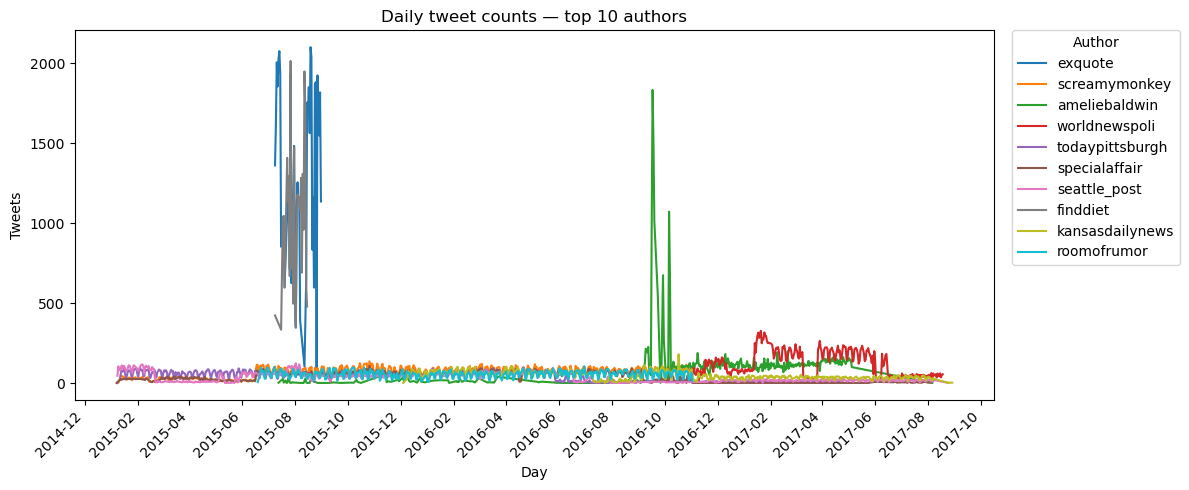

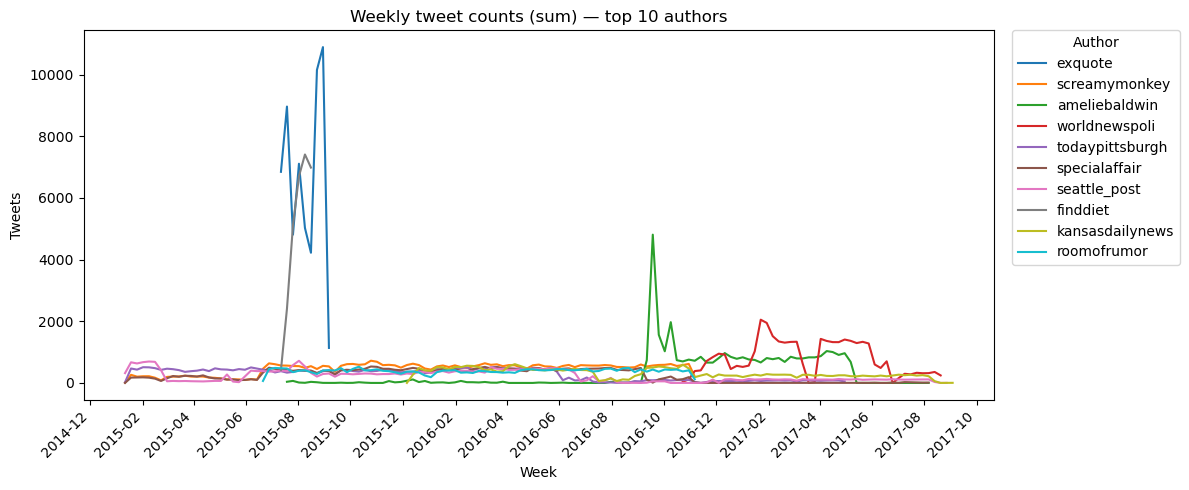

In [107]:
top_authors_rows = (
    df.groupBy("author")
      .agg(count("*").alias("n_tweets"))
      .orderBy(desc("n_tweets"))
      .limit(10)
      .collect()
)
top_authors = [r["author"] for r in top_authors_rows]
print("Top authors:", top_authors)

df_top_authors = df.filter(col("author").isin(top_authors))
df_top_authors_daily = (
    df_top_authors
      .withColumn("day", to_date("publish_date"))
      .groupBy("author", "day")
      .agg(count("*").alias("tweet_count"))
      .orderBy("author", "day")
)

pdf = df_top_authors_daily.toPandas()
pdf["day"] = pd.to_datetime(pdf["day"])

plt.figure(figsize=(12, 5))
for a in top_authors:
    sub = pdf.loc[pdf["author"] == a].sort_values("day")
    plt.plot(sub["day"], sub["tweet_count"], label=a)

plt.title("Daily tweet counts — top 10 authors")
plt.xlabel("Day"); plt.ylabel("Tweets")
plt.xticks(rotation=45, ha="right")
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.legend(title="Author", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0.)
plt.tight_layout()
plt.show()

weekly = (
    pdf
    .set_index("day")
    .groupby("author")["tweet_count"]
    .resample("W")
    .sum()
    .reset_index()
)

plt.figure(figsize=(12, 5))
for a in top_authors:
    sub = weekly.loc[weekly["author"] == a].sort_values("day")
    plt.plot(sub["day"], sub["tweet_count"], label=a)

plt.title("Weekly tweet counts (sum) — top 10 authors")
plt.xlabel("Week"); plt.ylabel("Tweets")
plt.xticks(rotation=45, ha="right")
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.legend(title="Author", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0.)
plt.tight_layout()
plt.show()

If we take the example of @ameliebaldwin (green), as it is one of the author with the biggest peak but also with a long and continuous activity, we can divide its activity in several phases:

**1. In 2015**: posts per day are low with about 1–6 tweets per day.

**2. Late 2015**:  spikes appear with 30 to 50 tweets per day.

**3. In 2016:** sudden large increases with peaks of 200 tweets per day minimum.

This reflects a classic playbook of sockpuppet growth and weaponization:

Its behavior can also be describe as a 1st phase of "Warm-up" (in 2015) and then "Activation" (in 2016).

The 1st is characterized by low-volume posting helping to build credibility, avoid platform detection, accumulate initial followers and try as much as possible to appear human.

**Activation can be characterized by massive spikes starting shortly before the 2016 US election**.

To finish the temporal analysis, we looked at a possible pattern arising from the account category during time. For this, we compute the total number of tweet per category and then per year, first in a table and then we plotted it in an area format to be more easily interpreted.

StatementMeta(, 0c55ff1a-6d27-440c-ab65-b084db287c55, 110, Finished, Available, Finished)

+----+----------------+-----------+
|year|account_category|tweet_count|
+----+----------------+-----------+
|2012|hashtaggamer    |119        |
|2012|lefttroll       |52         |
|2012|nonenglish      |317        |
|2013|lefttroll       |85         |
|2013|nonenglish      |114        |
|2014|fearmonger      |127        |
|2014|hashtaggamer    |6430       |
|2014|lefttroll       |5          |
|2014|newsfeed        |25         |
|2014|nonenglish      |282        |
|2014|righttroll      |784        |
|2014|unknown         |69         |
|2015|commercial      |120360     |
|2015|fearmonger      |10963      |
|2015|hashtaggamer    |32227      |
|2015|lefttroll       |34136      |
|2015|newsfeed        |131061     |
|2015|nonenglish      |351714     |
|2015|righttroll      |135919     |
|2015|unknown         |5064       |
|2016|commercial      |1240       |
|2016|fearmonger      |46         |
|2016|hashtaggamer    |170379     |
|2016|lefttroll       |217590     |
|2016|newsfeed        |30667

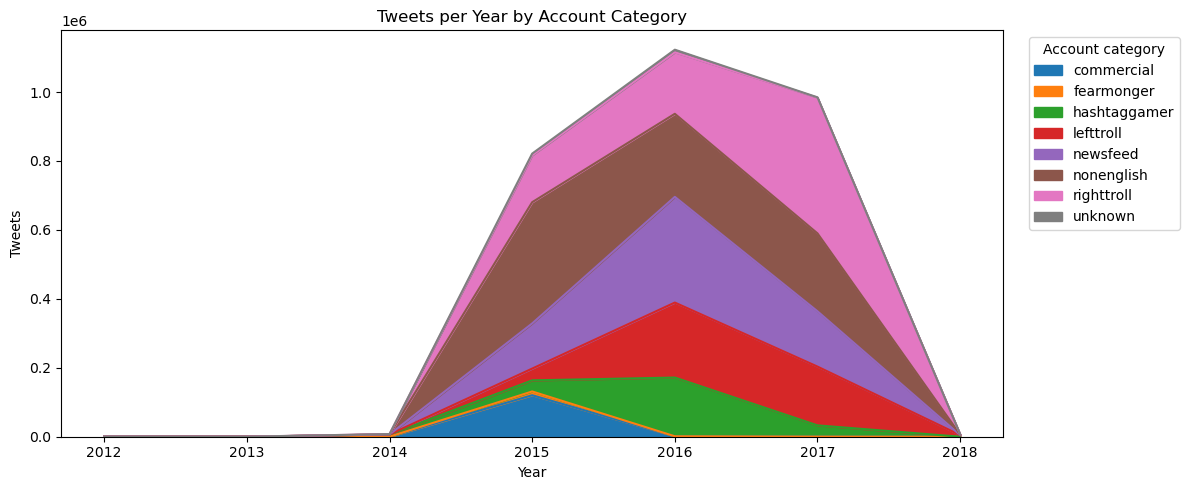

In [108]:
df_year_cat = (
    df.withColumn("year", year("publish_date"))
      .groupBy("year", "account_category")
      .agg(count("*").alias("tweet_count"))
      .orderBy("year", "account_category")
)

df_year_cat.show(50, truncate=False)


df_ts = df.withColumn("publish_ts", F.to_timestamp("publish_date")).filter(F.col("publish_ts").isNotNull())
df_year_cat = (df_ts
    .withColumn("year", year("publish_ts"))
    .groupBy("year", "account_category")
    .agg(count("*").alias("tweet_count"))
    .orderBy("year", "account_category"))

pdf = df_year_cat.toPandas()
pivot = (pdf
         .pivot(index="year", columns="account_category", values="tweet_count")
         .fillna(0)
         .sort_index())

plt.figure(figsize=(12,5))
pivot.plot(kind="area", stacked=True, ax=plt.gca())
plt.title("Tweets per Year by Account Category")
plt.xlabel("Year"); plt.ylabel("Tweets")
plt.legend(title="Account category", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

Year-by-year analysis reveals the operational timeline of the IRA campaign. After minimal activity in 2012–2013, 2014 marks the experimental testing phase especially with the sudden growth of hastaggamer (6,430). 

A massive scale-up occurs in 2015. This year marks the huge numbers accross each activity to make each of them covering a very specific role

- dual political personas with righttroll and  lefttroll

- newsfeed accounts to fake local news

- commercial accounts to built credibility 

- hashtaggamer to manipulate trending hashtags 

It was followed by peak activity during the 2016 U.S. election. Despite the end of the election cycle, high-volume posting continues into 2017, especially around divisive social events. 

Nearly all categories sharply decline in 2018, coinciding with platform takedowns and public exposure of the IRA network.

### Interpretation of all temporal outputs combined

From the analysis we conducted, it is possible to divide the timeline in 6 different states and their major features.

**Phase 0 - Setup (2012–2013)**

It is characterized by a very low number of tweets and coming from only a few random categories (Nonenglish and Lefttroll). It is likely the onboarding of initial personas.

**Phase 1 - Testing (2014)**

The first experiments stated to appear with fake news ("Newsfeed") along hashtag manipulation with the accounts from the "Hashtaggamer" as well as political category ("Righttroll")

**Phase 2 - Rapid Expansion (2015)**

It is in 2015 that all starts for real. All categories grow significantly. The different categories are clearly distinguished and established:

- Lefttroll: BLM, civil rights

- Righttroll: patriot, MAGA

- Newsfeed: local fake news

- Hashtaggamer: trend hijacking

- Commercial: credibility building

**Phase 3 - Peak operations (2016)**

The posting volume reaches hundreds of thousands. All major categories go active and there is multiple daily bursts feature of an heavy coordination. This year aligns perfectly with US presidential election interference.

**Phase 4 - Post-election polarization (2017)**

After the US election, we can still observe very high posting during US social tensions (Charlottesville, immigration debates). The troll accounts (right and left) continue narrative warfare.

**Phase 5 - Exposure and shutdown (2018)**

The last phase see the activity collapses. It is mainly due to U.S. Senate investigations about election interference as well as Twitter transparency reports and the IRA public exposure.

## 5. Text Analysis

Starting from now and for the whole Text Analysis, we choose to us only the English tweets to make the content analysis easily understandable. Also, they are the vast majority of the tweets as the targeted audience is in the United States as the known goal of IRA is to influence the US political environment from 2014 to 2018.

In [109]:
df_en = df.filter(col("language") == "english")
print("English tweets:", df_en.count())

StatementMeta(, 0c55ff1a-6d27-440c-ab65-b084db287c55, 111, Finished, Available, Finished)

English tweets: 2115482


To do our content analysis, we first cleaned it. We ensure that by:

- making everything lowercase

- removing URLs and replacing it with a space

- removing @mentions

- removing the # symbol

- removing any non-alphanumeric and non-space characters like punctuation, emojis, accented letters and turning them into spaces

- collapsing multiple spaces into a single space.

Then we turned the cleaned text into tokens and then removing stopwords such as "the", "be", "and".

In [110]:
df_en_clean = (
    df_en.withColumn("text_clean",
        lower(col("content"))
    )
    .withColumn("text_clean", regexp_replace(col("text_clean"), r"http\S+", " "))
    .withColumn("text_clean", regexp_replace(col("text_clean"), r"@\w+", " "))
    .withColumn("text_clean", regexp_replace(col("text_clean"), r"#", " "))
    .withColumn("text_clean", regexp_replace(col("text_clean"), r"[^a-zA-Z0-9\s]", " "))
    .withColumn("text_clean", regexp_replace(col("text_clean"), r"\s+", " "))
)

df_en_clean.select("content", "text_clean").show(5, truncate=False)

StatementMeta(, 0c55ff1a-6d27-440c-ab65-b084db287c55, 112, Finished, Available, Finished)

+-------------------------------------------------------------------------------------------------------------------------------------+------------------------------------------------------------------------------------------------------+
|content                                                                                                                              |text_clean                                                                                            |
+-------------------------------------------------------------------------------------------------------------------------------------+------------------------------------------------------------------------------------------------------+
|"Coming together is a beginning. Keeping together is progress. Working together is success." Henry Ford http://t.co/9xj6JINN         | coming together is a beginning keeping together is progress working together is success henry ford   |
|To Follow or Not To Follow: Should Small Bu

In [111]:
tokenizer = Tokenizer(inputCol="text_clean", outputCol="tokens")
df_tokens = tokenizer.transform(df_en_clean)

remover = StopWordsRemover(
    inputCol="tokens",
    outputCol="tokens_clean"
)

df_tokens = remover.transform(df_tokens)

df_tokens.select("content", "tokens_clean").show(5, truncate=False)

StatementMeta(, 0c55ff1a-6d27-440c-ab65-b084db287c55, 113, Finished, Available, Finished)

+-------------------------------------------------------------------------------------------------------------------------------------+-----------------------------------------------------------------------------------------------------+
|content                                                                                                                              |tokens_clean                                                                                         |
+-------------------------------------------------------------------------------------------------------------------------------------+-----------------------------------------------------------------------------------------------------+
|"Coming together is a beginning. Keeping together is progress. Working together is success." Henry Ford http://t.co/9xj6JINN         |[, coming, together, beginning, keeping, together, progress, working, together, success, henry, ford]|
|To Follow or Not To Follow: Should Small Busine

### Top Words

First, we looked at the **top words** used ( apart from stopwords as we removed above) and we display the top 50.

In [112]:
df_words = df_tokens.select(explode(col("tokens_clean")).alias("word"))

df_words = df_words.filter(F.length(col("word")) > 2)

top_words_overall = (
    df_words.groupBy("word")
            .count()
            .orderBy(desc("count"))
)

print("Top 50 words (overall, English):")
top_words_overall.show(50, truncate=False)

StatementMeta(, 0c55ff1a-6d27-440c-ab65-b084db287c55, 114, Finished, Available, Finished)

Top 50 words (overall, English):
+---------+------+
|word     |count |
+---------+------+
|trump    |161267|
|news     |152285|
|new      |70478 |
|police   |58816 |
|man      |55826 |
|people   |54782 |
|sports   |51734 |
|obama    |48505 |
|world    |46994 |
|get      |46372 |
|like     |46350 |
|politics |43776 |
|one      |42700 |
|amp      |42442 |
|workout  |42259 |
|black    |39704 |
|breaking |37901 |
|video    |37518 |
|hillary  |36199 |
|says     |36063 |
|president|31921 |
|white    |31528 |
|time     |31419 |
|day      |31083 |
|clinton  |30564 |
|local    |30328 |
|via      |28646 |
|state    |28132 |
|year     |27985 |
|make     |27347 |
|america  |27054 |
|need     |26606 |
|know     |26361 |
|good     |26056 |
|woman    |25370 |
|love     |25169 |
|want     |24660 |
|first    |24501 |
|back     |24447 |
|life     |23920 |
|say      |23592 |
|right    |22586 |
|killed   |22492 |
|house    |22184 |
|media    |21827 |
|today    |21733 |
|see      |21288 |
|never    |20843 

**Most of the vocabulary is political** (the word "Trump" referring to the then candidate to the presidential election is top 1 with more than 161k use), racial, or news-related. This confirms that the IRA content was not random social tweeting but rather explicitly structured to:

- push political narratives

- amplify divisive topics

- flood the online space with news-like content

To go deeper on the analysis of the most used words, we tried to see if the top words by account category represent correctly the behavior or aiming goal of each category. 

In [113]:
main_cats = ["righttroll", "lefttroll", "newsfeed", "nonenglish"]

df_cat_words = (
    df_tokens
      .filter(col("account_category").isin(main_cats))
      .select("account_category", explode(col("tokens_clean")).alias("word"))
      .filter(F.length(col("word")) > 2)
)

for cat in main_cats:
    print(f"\n=== Top 30 words for {cat.upper()} ===")
    (
        df_cat_words.filter(col("account_category") == cat)
                    .groupBy("word")
                    .count()
                    .orderBy(desc("count"))
                    .show(30, truncate=False)
    )

StatementMeta(, 0c55ff1a-6d27-440c-ab65-b084db287c55, 115, Finished, Available, Finished)


=== Top 30 words for RIGHTTROLL ===
+---------+------+
|word     |count |
+---------+------+
|trump    |107333|
|obama    |34790 |
|hillary  |29508 |
|breaking |29069 |
|amp      |24025 |
|video    |21871 |
|new      |21731 |
|people   |21716 |
|news     |21380 |
|president|19570 |
|america  |18482 |
|clinton  |18279 |
|like     |17656 |
|one      |16781 |
|maga     |16456 |
|via      |15996 |
|media    |15049 |
|tcot     |14550 |
|get      |14075 |
|pjnet    |12777 |
|white    |12639 |
|cnn      |12332 |
|time     |11837 |
|look     |11763 |
|american |11159 |
|says     |10891 |
|know     |10824 |
|want     |10791 |
|top      |10711 |
|right    |10623 |
+---------+------+
only showing top 30 rows


=== Top 30 words for LEFTTROLL ===
+----------------+-----+
|word            |count|
+----------------+-----+
|black           |26994|
|trump           |24668|
|people          |19413|
|get             |15999|
|amp             |15778|
|like            |15304|
|new             |14828|
|whit

**<u>Righttroll :</u>**

The top words used by righttroll includes:

- “trump”

- “obama”

- “hillary”

- “maga”

- “america”

- “cnn”

- “white”

This can be consistent as a Righttroll accounts heavily try to push pro-Trump messages as well as anti-Obama or Clinton sentiment, and speak mainly about conservative themes such as MAGA, patriotism or media distrust.

This matches documented IRA strategy: **Amplify right-wing anger, patriotism, and anti-establishment rhetoric.**

<u>**Lefttroll:**</u>

The top words includes:

- “black”

- “police”

- “blacklivesmatter”

- “people”

- “women”


Lefttroll accounts are knowned to focuse on US racial tensions, police violence and linked to that, "Black Lives Matter", but also try to create emotional engagement.

These accounts tried to **appeal to liberal or minority communities and increase polarization.**

**<u>Newsfeed:</u>**

Their top words are: 

- “news”

- “sports”

- “police”

- “politics”

- “local”

- “killed”

- “health”

- “shooting”

These accounts behave like fake automated news aggregators. Thus, their goal are to publish high-volume “breaking news”, build large followings and become trusted sources that other troll accounts can retweet.

**They create credibility and viral reach for political narratives**.


<u>**Nonenglish:**</u>

- “russia”

- “syrian”

- “putin”

- “war”

- “aleppo”

These are Russia-oriented geopolitical accounts and pushing Syria war narratives as well as pro-Russian foreign policy and anti-Western framing.

Their main use is to **serve global geopolitical messaging**.

### Hashtag analysis

An interesting feature of Twitter is the fact that it's possible to put hashtag in the content of the tweet. It's then possible to search a subject with the hashtag, it is most of the time associated with the main theme of the tweet and it is by the hashtag that a trend came viral. That is why we decided to analyze the most used hashtags and display the top 50.

In [114]:
df_hashtags = (
    df_en
      .withColumn("token", explode(split(col("content"), " ")))
      .filter(col("token").startswith("#"))
      .groupBy("token")
      .count()
      .orderBy(desc("count"))
)

print("Top 50 hashtags (English tweets):")
df_hashtags.show(50, truncate=False)

StatementMeta(, 0c55ff1a-6d27-440c-ab65-b084db287c55, 116, Finished, Available, Finished)

Top 50 hashtags (English tweets):
+------------------------+------+
|token                   |count |
+------------------------+------+
|#news                   |126819|
|#sports                 |48329 |
|#politics               |39622 |
|#world                  |27525 |
|#local                  |25787 |
|#TopNews                |15135 |
|#MAGA                   |12000 |
|#health                 |11462 |
|#tcot                   |11206 |
|#BlackLivesMatter       |11084 |
|#business               |10821 |
|#PJNET                  |10198 |
|#tech                   |8216  |
|#entertainment          |7513  |
|#top                    |7324  |
|#Cleveland              |6672  |
|#crime                  |6499  |
|#TopVideo               |6452  |
|#environment            |5778  |
|#ISIS                   |5066  |
|#mar                    |4854  |
|#Miami                  |4520  |
|#breaking               |4490  |
|#Trump                  |4471  |
|#topl                   |4383  |
|#SanJose     

The hashtags follow mainly the same findings than the top words. They can be divided in 4 main categories:

- Political

- Social and identity

- News related

- Radicalizing 

It strongly reinforce the narrative roles identified earlier. It is also an **evidence of coordinated multi-segment targeting.**

We did the same for the **top hashtags by account category:**

In [115]:
df_hashtags_cat = (
    df_en
      .filter(col("account_category").isin(main_cats))
      .withColumn("token", explode(split(col("content"), " ")))
      .filter(col("token").startswith("#"))
      .select("account_category", col("token").alias("hashtag"))
)

for cat in main_cats:
    print(f"\n=== Top 30 hashtags for {cat.upper()} ===")
    (
        df_hashtags_cat.filter(col("account_category") == cat)
                       .groupBy("hashtag")
                       .count()
                       .orderBy(desc("count"))
                       .show(30, truncate=False)
    )

StatementMeta(, 0c55ff1a-6d27-440c-ab65-b084db287c55, 117, Finished, Available, Finished)


=== Top 30 hashtags for RIGHTTROLL ===
+---------------+-----+
|hashtag        |count|
+---------------+-----+
|#MAGA          |11717|
|#tcot          |10298|
|#PJNET         |9945 |
|#top           |7323 |
|#news          |6673 |
|#mar           |4854 |
|#topl          |4383 |
|#IslamKills    |3887 |
|#2A            |3850 |
|#FAKENEWS!     |3752 |
|#WakeUpAmerica |3538 |
|#Trump         |3289 |
|#TCOT          |3262 |
|#ccot          |3141 |
|#GOPDebate     |3091 |
|#amb           |2895 |
|#TrumpTrain    |2601 |
|#may           |2567 |
|#DemnDebate    |2407 |
|#VegasGOPDebate|2202 |
|#CCOT          |2190 |
|#pjnet         |2186 |
|#Trump2016     |2179 |
|#ISIS          |2163 |
|#sports        |2144 |
|#th            |2122 |
|#politics      |2105 |
|#DemDebate     |2069 |
|#local         |1957 |
|#Brussels      |1881 |
+---------------+-----+
only showing top 30 rows


=== Top 30 hashtags for LEFTTROLL ===
+---------------------+-----+
|hashtag              |count|
+------------------

<u>**RighTroll Accounts**</u>**<u>: Highly Polarized, Conservative Messaging</u>**

Right-leaning troll accounts systematically amplify themes aligned with U.S. conservative politics.
Their most frequent hashtags include:

- #MAGA, #TrumpTrain, #Trump: strong support for Donald Trump.

- #tcot, #PJNET, #GOPDebate: core conservative Twitter communities and activism hubs.

- #IslamKills, #ISIS, #2A: framing around nationalism, security, and gun rights.

- #FakeNews, #WakeUpAmerica, #Breaking: disinformation-aligned narratives that question the media and amplify outrage.

RightTroll accounts are engineered to **energize conservative voters, push polarizing right-wing narratives, and mobilize ideological engagement around Republican issues.**


**<u>LeftTroll Accounts</u><u> : Race & Social Justice Framing</u>**

Left-leaning troll accounts focus on social justice, racial inequality, and youth-oriented cultural themes.
Their most common hashtags include:

- #BlackLivesMatter, #PoliceBrutality, #BlackTwitter, #BLM: strong focus on race, policing, and civil rights activism.

- #StayWoke, #BlackHistoryMonth, #NoDAPL: activist and progressive political culture.

- #NowPlaying, #hiphop, #RAPstationRadio: youth-targeted cultural engagement.

- #NYC, #God, #music, #rap: lifestyle and identity-based tagging used to broaden reach.

LeftTroll accounts **amplify racial and social justice grievances, promote progressive cultural identity, and embed themselves into youth digital communities.**

<u>**NewsFeed Accounts : General US News Cycle**</u>

Top hashtags align with mainstream news topics:

- #news, #sports, #politics, #world

- #shooting, #ISIS, #breaking: crime and public safety

- #Cleveland, #Miami, #Chicago, #Texas: local-focus tags

The NewsFeed category acts like a **neutral amplifier, pushing high-volume, agenda-setting topics without explicit ideological framing.**

**<u>NonEnglish Accounts : Geopolitics & European Issues</u>**

Most common topics:

- Syria, Russia, ISIS, Aleppo, Ukraine

- Brexit: #BritainInOut, #RemainInEU, #BrexitOrNot

- European political leaders: Merkel, Putin

Non-English accounts reflect **international geopolitical concerns, mostly relating to Middle East conflicts and EU divisions, typical of influence operations targeting European audiences.**

Here, the goal is to find who trolls target by computing the most used mentions, that is to say the user name on Twitter.

In [116]:
df_mentions = (
    df_en
      .withColumn("token", explode(split(col("content"), " ")))
      .filter(col("token").startswith("@"))
      .groupBy("token")
      .count()
      .orderBy(desc("count"))
)

print("Top 50 mentioned users (English tweets):")
df_mentions.show(50, truncate=False)

StatementMeta(, 0c55ff1a-6d27-440c-ab65-b084db287c55, 118, Finished, Available, Finished)

Top 50 mentioned users (English tweets):
+----------------+-----+
|token           |count|
+----------------+-----+
|@realDonaldTrump|8075 |
|@midnight       |7989 |
|@YouTube        |3795 |
|@POTUS          |3474 |
|@               |2744 |
|@HillaryClinton |2614 |
|@CNN            |2087 |
|@FoxNews        |1705 |
|@TalibKweli     |1522 |
|@josephjett     |1045 |
|@GiselleEvns    |974  |
|@WorldOfHashtags|965  |
|@CNNPolitics    |849  |
|@GOP            |848  |
|@BreitbartNews  |749  |
|@VanJones68     |741  |
|@seanhannity    |710  |
|@HashtagRoundup |702  |
|@AC360          |682  |
|@CNNSitRoom     |673  |
|@JakeTapper     |662  |
|@TheLeadCNN     |658  |
|@BrianStelter   |655  |
|@CNNI           |654  |
|@WolfBlitzer    |652  |
|@DonLemon       |652  |
|@truthfeednews  |650  |
|@AnaNavarro     |649  |
|@AndersonCooper |647  |
|@nytimes        |598  |
|@tedcruz        |589  |
|@jstines3:      |569  |
|@BarackObama    |548  |
|@deray          |532  |
|@guntrust       |512  |
|@Speaker

<u>**Most Mentioned Users (English Tweets)**</u>

Top-mentioned accounts are overwhelmingly political actors or media outlets, including:

- Presidential candidate: @realDonaldTrump, @HillaryClinton

- News actors: @FoxNews, @CNN, @POTUS

- Conservative influencers: @seanhannity, @BreitbartNews, @GOP

- Democrat-aligned voices: @BarackObama, @BernieSanders

- Journalists: @jaketapper, @andersoncooper, @donlemon, @brianstelter

Mentions concentrate around **high-visibility political figures and media**, suggesting that these accounts attempt to insert themselves into public political conversations and manipulate trending topics.

### Correlation between the number of words and the number of followers

In addition, we looked at a potential correlation between the number of words in the content of a tweet and the number of followers. The hypothesis is that **if there is a low or even negative correlation, the accounts which have to more followers tend to write shorter tweets**, meaning maybe that the message of the tweet they want to convey need less explanation or long sentence which can be lost.

In [117]:
#Correlation: word_count vs followers

df_corr = (
    df_en
      .select("word_count", "followers")
      .na.drop()
)

correlation = df_corr.select(corr("word_count", "followers")).collect()[0][0]
print("Correlation between word_count and followers (English tweets):", correlation)

StatementMeta(, 0c55ff1a-6d27-440c-ab65-b084db287c55, 119, Finished, Available, Finished)

Correlation between word_count and followers (English tweets): -0.11722044209049846


The correlation between the number of word per tweet and the number of followers is –0.117

We can interpret this slight negative correlation as the fact that accounts with more followers tend to write slightly shorter tweets. **High-follower accounts often publish short**, punchy messages that drive engagement.

### Top 10 topics

To uncover recurring themes in the English tweets but without predefining labels, we decided to do a **topic modeling on tweets** by applying **Latent Dirichlet Allocation (LDA)**. We did not use a sample but taking the entire dataset.

CountVectorizer builds a vocabulary of maximum 20k terms and converts each tweet into a sparse count vector, ignoring very rare words.

For the LDA model, we fit k=10 topics. Each topic is a probability distribution over words and each tweet gets a distribution over topics.

We list the **top 15 words** per topic, mapping term indices back to words via the learned vocabulary. These top words provide human-readable labels for each theme.

In [118]:
#Topic Modelling with LDA
from pyspark.ml.feature import CountVectorizer
from pyspark.ml.clustering import LDA

# Sample 10% of English tweets for topic modeling
df_sample = df_tokens.sample(False, 0.1, seed=42).select("tokens_clean")

# Build vocabulary
cv = CountVectorizer(inputCol="tokens_clean", outputCol="features", vocabSize=20000, minDF=20)
cv_model = cv.fit(df_sample)
df_features = cv_model.transform(df_sample)

# Train LDA with e.g. 10 topics
lda = LDA(k=10, maxIter=20, featuresCol="features", seed=42)
lda_model = lda.fit(df_features)

topics = lda_model.describeTopics(15)
vocab = cv_model.vocabulary

# Map term indices to words
topics_words = topics.rdd.map(
    lambda row: [vocab[idx] for idx in row['termIndices']]
).collect()

for i, topic_words in enumerate(topics_words):
    print(f"\n=== Topic {i} ===")
    print(", ".join(topic_words))

StatementMeta(, 0c55ff1a-6d27-440c-ab65-b084db287c55, 120, Finished, Available, Finished)


=== Topic 0 ===
, like, m, need, got, make, get, exercise, gt, pjnet, life, love, see, lol, last

=== Topic 1 ===
ali, subway, askem, gucci, amen, artyoucanhear, chip, mariowoods, derailment, ouch, mane, breakingnews, sanfrancisco, progressives, understanding

=== Topic 2 ===
sports, news, , new, local, 2, game, year, man, san, school, orleans, 1, state, world

=== Topic 3 ===
foke, kelly, great, education, secretary, conway, megyn, valentinesdayin3words, devos, marco, , kellyanne, constitutional, rubio, betsy

=== Topic 4 ===
, workout, know, one, news, man, time, go, us, world, good, old, amp, rt, muslim

=== Topic 5 ===
oil, joe, dad, biden, tacos, disgusting, kathy, israeli, griffin, palestinian, bought, fishtv, tiny, bars, teeth

=== Topic 6 ===
trump, , hillary, rt, video, via, breaking, clinton, tcot, obama, news, good, fake, watch, anti

=== Topic 7 ===
, m, news, want, re, new, day, world, going, syria, sports, isis, us, life, business

=== Topic 8 ===
, trump, news, rt, poli

The 10 LDA topics show clear thematic clusters:

**<u>Topic 0: Everyday conversation & filler content</u>**

- Words like “like”, “thanks”, “make”, “free”, “need”, “everything”, etc.

Likely represents lightweight engagement tweets used to appear human.

**<u>Topic 2 & 4: News and public safety</u>**

- “news”, “police”, “sports”, “shooting”, “killed”, “state”, “north”, “islamic”.

Reflects the push toward high-volume news amplification.

**<u>Topic 5 & 6: Conservative political narratives</u>**

- “fakenews”, “cnn”, “maga”, “trump”, “breaking”, “clinton”, “obama”

Mirrors the RighTroll hashtag and word patterns.

**<u>Topic 7: Middle East / ISIS / geopolitics</u>**

- “isis”, “us”, “people”, “get”, “obama”, “american”, “pjnet”

Likely overlaps with Non-English and geopolitical messaging.

**<u>Topic 8: Racial & political themes</u>**

- “black”, “white”, “people”, “politics”, “news”

Similar to Lefttroll racial content.

**<u>Topic 9: Cultural / entertainment</u>**

- “movie”, “bowl”, “walk”, “daily”, “staywoke”, “life”, “mike”

Indicates attempts to blend in with non-political content.


### Overall narrative architecture

The text analysis phase reveals a **highly structured and intentional narrative strategy** deployed by the IRA accounts. By examining the cleaned text, token frequencies, hashtags, user mentions, tweet lengths, and topic models, a clear architecture of influence emerges.
Across categories and languages, the trolls do not behave randomly; instead, each account type contributes to a coordinated ecosystem of themes, emotional triggers, and political messaging.

The **main takeaways** are :

- Dominant themes and vocabulary revealing coordinated messaging as each category plays a distinct role in a broad propaganda ecosystem.

- Hashtag use reinforces political and geopolitical narratives. They mirror the word patterns and emphasize agenda-building strategies and show that the narratives are not random but follow trending, divisive, high-engagement topics.

- Mention networks target high-profile figures and media outlets. They are used strategically to maximize reach, visibility, and controversy.

- There is definitively distinct narrative clusters. The IRA messaging mixes news, politics, identity issues, and entertainment, mirroring real social media ecosystems to increase credibility and infiltration.


The text analysis reveals a **deliberately engineered narrative architecture across IRA account categories**. 

Each account type promotes distinct themes: 
- Righttroll accounts amplify conservative political rhetoric
- Lefttroll accounts emphasize racial, social justice, and anti-police narratives
- Newsfeed accounts mimic neutral local journalism
- Non-English accounts focus on geopolitical conflicts involving Russia, Syria, or global crises

Hashtag and user mention patterns reinforce these strategies by systematically attaching troll content to high-visibility political actors, mainstream media outlets, and trending polarized topics. Differences in tweet length and lexical style show that each category adopts communication patterns suited to its intended audience and purpose. The weak correlation between tweet length and followers suggests that reach was artificially inflated through coordinated networks rather than organic engagement. LDA topic modelling confirms the presence of stable clusters of discourse—politics, crime, identity issues, geopolitics, and entertainment—indicating a multi-layered approach designed to infiltrate multiple communities simultaneously. 

Overall, the IRA operates as a coordinated ecosystem of thematic actors, each pushing complementary narratives that collectively maximize polarization and influence.


## 6. Network Analysis


The Russian IRA dataset describes **coordinated online activity**.

Retweets and mentions naturally form a network of interactions:

- <u>Nodes:</u> Twitter accounts

- E<u>dges</u>: Retweets or mentions (A → B means “A retweeted/mentioned B”)

A network perspective reveals structural patterns that do not appear from content analysis alone, such as:

- Which accounts acted as amplifiers

- Which accounts acted as influencers

- Whether specific troll categories coordinated with each other

- Information flows between groups (e.g., RightTroll → NewsFeed)


**Network analysis is essential when studying coordinated online behaviour**, because trolls and bot-like accounts often operate through patterns of retweeting, mentioning and amplifying specific narratives. Even without full follower-network data (which the original IRA dataset does not provide), we can infer relationships by looking at retweet and mention behaviour.

<u>Tweets contain two very useful signals:</u>

**a) Retweets (retweet = 1)**

If account A retweets account B, it behaves as:

A → B

A amplifies B

A treats B as a source of information. This is a strong implicit network tie.

**b) Mentions using @username**

Even when not flagged as a retweet, if a tweet contains @SomeUser it signals attention or targeting.

Therefore, extracting edges as: 

- src = author  

- dst = first mentioned user

gives us a realistic “interaction network”.

In [119]:
df_full = df

StatementMeta(, 0c55ff1a-6d27-440c-ab65-b084db287c55, 121, Finished, Available, Finished)

### The retweet edges

First, we build the “retweet / mention” edges. For that, we extracted the first mentioned user from content and then building the edge list.

In [120]:
df_rt = df_full.withColumn(
    "mentioned_user",
    F.regexp_extract(F.col("content"), r"@([A-Za-z0-9_]+)", 1)
)

rt_edges = (
    df_rt
    .filter((F.col("retweet") == 1) & (F.col("mentioned_user") != ""))
    .select(
        F.col("author").alias("src"),
        F.col("mentioned_user").alias("dst")
    )
)

print("Number of retweet edges (with @mention):", rt_edges.count())
rt_edges.show(10, truncate=False)

StatementMeta(, 0c55ff1a-6d27-440c-ab65-b084db287c55, 122, Finished, Available, Finished)

Number of retweet edges (with @mention): 156040
+---------+---------------+
|src      |dst            |
+---------+---------------+
|moneyform|2VANESSA0Cassid|
|moneyform|Flannerynen    |
|moneyform|HennessyNC     |
|moneyform|spoonthaman34  |
|moneyform|RESWERVED      |
|moneyform|pepsivol       |
|moneyform|LightHeavens   |
|moneyform|raecchii       |
|moneyform|obgynlanda982  |
|moneyform|AlleyKat2      |
+---------+---------------+
only showing top 10 rows



To make it more easy to understand, we used a **network visualization** (NetworkX). For that we count the number of time the relationship author -> 1st mentioned user occurs (src -> dst) and we choose the top 80 nodes.

StatementMeta(, 0c55ff1a-6d27-440c-ab65-b084db287c55, 123, Finished, Available, Finished)

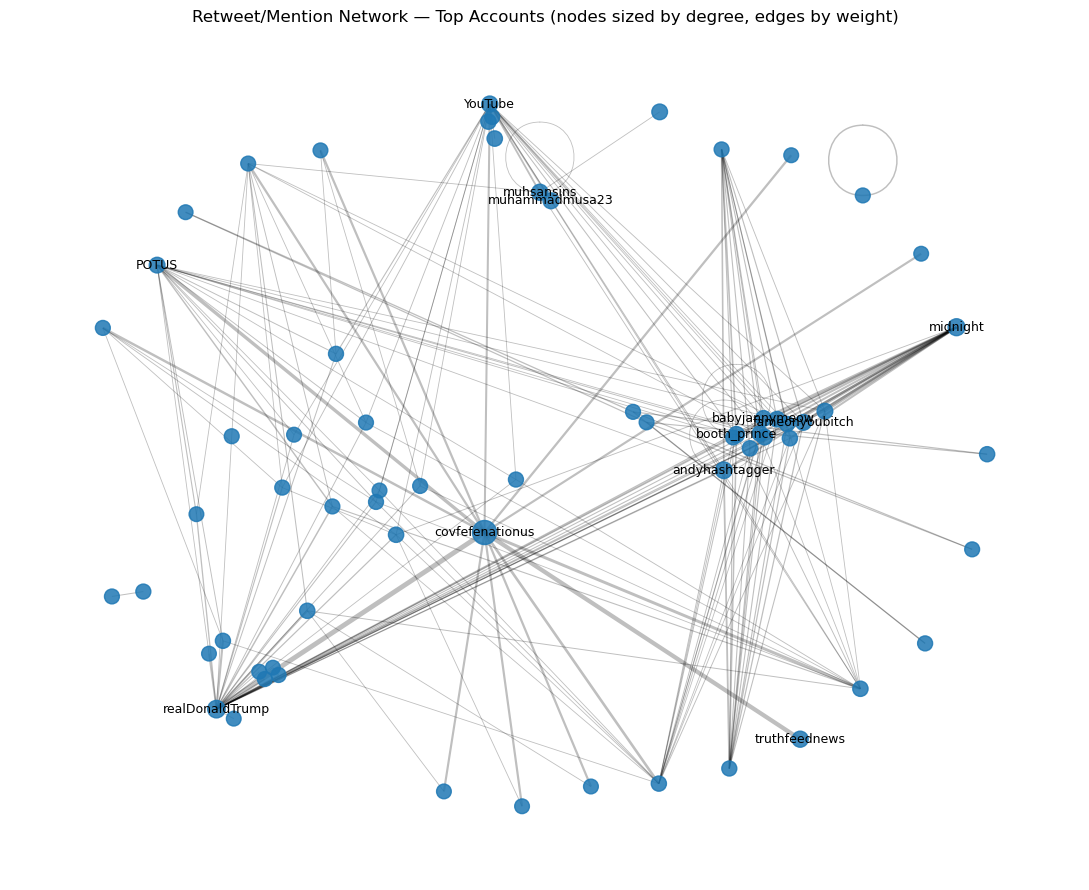

In [121]:
rt_edges = (
    df_rt
    .filter((F.col("retweet") == 1) & (F.col("mentioned_user") != ""))
    .select(F.col("author").alias("src"), F.col("mentioned_user").alias("dst"))
)

edges_w = (rt_edges
           .groupBy("src", "dst")
           .agg(F.count("*").alias("weight")))

out_deg = edges_w.groupBy("src").agg(F.sum("weight").alias("out_w")).withColumnRenamed("src","node")
in_deg  = edges_w.groupBy("dst").agg(F.sum("weight").alias("in_w")).withColumnRenamed("dst","node")
deg = (out_deg.unionByName(in_deg, allowMissingColumns=True)
              .groupBy("node").agg(F.sum(F.coalesce(F.col("out_w"),F.lit(0)) + F.coalesce(F.col("in_w"),F.lit(0))).alias("deg_w"))
              .orderBy(F.col("deg_w").desc()))

TOP_K = 80  
top_nodes = [r["node"] for r in deg.limit(TOP_K).collect()]

edges_sub = edges_w.filter(F.col("src").isin(top_nodes) & F.col("dst").isin(top_nodes))

pdf_edges = edges_sub.toPandas()
pdf_nodes = deg.filter(F.col("node").isin(top_nodes)).toPandas()

import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

G = nx.from_pandas_edgelist(pdf_edges, source="src", target="dst", edge_attr="weight", create_using=nx.DiGraph())

deg_map = {r["node"]: r["deg_w"] for _, r in pdf_nodes.iterrows()}
sizes = np.array([deg_map.get(n, 1) for n in G.nodes()], dtype=float)
sizes = 200 * (sizes / sizes.max())**0.6 + 100 

wts = np.array([d.get("weight",1) for _,_,d in G.edges(data=True)], dtype=float)
if len(wts) == 0:
    wts = np.array([1.0])
edge_widths = 0.5 + 3.0 * (wts / wts.max())**0.5

pos = nx.spring_layout(G, k=0.35, iterations=200, seed=42)

plt.figure(figsize=(11, 9))
nx.draw_networkx_edges(G, pos, width=edge_widths, alpha=0.25, arrows=False)
nx.draw_networkx_nodes(G, pos, node_size=sizes, alpha=0.85)

label_count = 20
top_labels = set([n for n,_ in sorted(deg_map.items(), key=lambda x: x[1], reverse=True)[:label_count]])
labels = {n: n for n in G.nodes() if n in top_labels}
nx.draw_networkx_labels(G, pos, labels=labels, font_size=9)

plt.title("Retweet/Mention Network — Top Accounts (nodes sized by degree, edges by weight)")
plt.axis("off"); plt.tight_layout(); plt.show()


It is very clear with this network that there are:

- Hubs accounts like realDonaldTrump, POTUS, YouTube which attract many incoming edges. It means they’re **frequent mention or retweet targets**.

- Many small nodes point into the same hubs creating star-shaped spokes. That’s classic amplification-numerous sockpuppets boosting a **few high-visibility handles to ride their reach**.

- On the right, tight mini-cluster can be seen. These are several nodes tightly connected to each other and to a shared target. That looks like a coordinated cell repeatedly mentioning/retweeting the same set of accounts.

- Self-loops and very thick edges that **repeat mentions from the same source to the same destination**.

- A few isolates or weakly tied nodes represented by peripheral actors with little cross-talk and which are likely single-purpose or short-lived personas.

The structure matches a hub-and-spoke amplification strategy. Many **IRA-linked accounts** funnelling attention toward a small set of public figures or platforms to piggyback on trending visibility.

The dense micro-cluster suggests orchestrated posting windows—useful to check against timestamps for synchronized bursts.

Emphasis on platforms (e.g. YouTube) alongside political figures hints at content routing to **push users off-platform to long-form assets**.


### Most common retweet relationship

Another interesting analysis is the most common retweet relationships meaning who retweets whom. With the IRA goal, this relationship can be translated as **which troll accounts most often retweet which “target” accounts**.

In [122]:
rt_pairs = (
    rt_edges
    .groupBy("src", "dst")
    .agg(F.count("*").alias("n_rt"))
    .orderBy(F.desc("n_rt"))
)

print("Top 20 retweet relationships:")
rt_pairs.show(20, truncate=False)


StatementMeta(, 0c55ff1a-6d27-440c-ab65-b084db287c55, 124, Finished, Available, Finished)

Top 20 retweet relationships:
+---------------+---------------+----+
|src            |dst            |n_rt|
+---------------+---------------+----+
|covfefenationus|realDonaldTrump|873 |
|covfefenationus|truthfeednews  |645 |
|covfefenationus|POTUS          |359 |
|covfefenationus|FoxNews        |256 |
|covfefenationus|HillaryClinton |186 |
|fameonyoubitch |midnight       |164 |
|elianlindsey   |midnight       |162 |
|covfefenationus|BreitbartNews  |155 |
|covfefenationus|elizabethforma |125 |
|covfefenationus|CNN            |122 |
|covfefenationus|Acosta         |121 |
|covfefenationus|WayneDupreeShow|120 |
|annieposhes    |midnight       |119 |
|covfefenationus|perfectsliders |115 |
|covfefenationus|Cernovich      |111 |
|covfefenationus|seanhannity    |110 |
|babyjannymeow  |midnight       |103 |
|covfefenationus|SenWarren      |102 |
|wokeluisa      |realDonaldTrump|102 |
|andydrewdaniels|midnight       |99  |
+---------------+---------------+----+
only showing top 20 rows



These strong ties indicate:

- systematic amplification

- targeted promotion

- coordinated messaging

This reveals clusters of behaviour consistent with the IRA operation.

### Degree centrality (in-degree / out-degree)

Retweets create a directed network. A source account retweets or mentions a destination account. Measuring **in-degree** (how many retweets an account receives) and **out-degree** (how many retweets an account sends) helps distinguish attractors from amplifiers. This reveals hub-and-spoke patterns, booster cells, and which personas act as megaphones versus magnets.

To do so, we build in-degree and out-degree metrics per user. Then we combine both views into degrees and add them together.

In [123]:
# In-degree: how often each user is retweeted (@dst)
in_deg = (
    rt_edges
    .groupBy("dst")
    .agg(
        F.countDistinct("src").alias("in_degree_users"),   # how many distinct accounts retweeted them
        F.count("*").alias("in_degree_edges")              # total number of retweets received
    )
    .withColumnRenamed("dst", "user")
)

# Out-degree: how often each user retweets others (@src)
out_deg = (
    rt_edges
    .groupBy("src")
    .agg(
        F.countDistinct("dst").alias("out_degree_users"),  # how many distinct accounts they retweet
        F.count("*").alias("out_degree_edges")             # total number of retweets sent
    )
    .withColumnRenamed("src", "user")
)

# Combine
degrees = (
    in_deg
    .join(out_deg, on="user", how="outer")
    .na.fill(0)
    .withColumn("total_edges", F.col("in_degree_edges") + F.col("out_degree_edges"))
)

print("Schema of network degrees:")
degrees.printSchema()

print("Top 20 most retweeted users (by in_degree_edges):")
degrees.orderBy(F.desc("in_degree_edges")).show(20, truncate=False)

print("Top 20 most active retweeters (by out_degree_edges):")
degrees.orderBy(F.desc("out_degree_edges")).show(20, truncate=False)


StatementMeta(, 0c55ff1a-6d27-440c-ab65-b084db287c55, 125, Finished, Available, Finished)

Schema of network degrees:
root
 |-- user: string (nullable = true)
 |-- in_degree_users: long (nullable = true)
 |-- in_degree_edges: long (nullable = true)
 |-- out_degree_users: long (nullable = true)
 |-- out_degree_edges: long (nullable = true)
 |-- total_edges: long (nullable = true)

Top 20 most retweeted users (by in_degree_edges):
+-----------------+---------------+---------------+----------------+----------------+-----------+
|user             |in_degree_users|in_degree_edges|out_degree_users|out_degree_edges|total_edges|
+-----------------+---------------+---------------+----------------+----------------+-----------+
|realDonaldTrump  |156            |1637           |0               |0               |1637       |
|midnight         |20             |1185           |0               |0               |1185       |
|rus_improvisation|422            |1144           |0               |0               |1144       |
|salty_1970       |389            |938            |0               |0 

**<u>1. Most influential users: e.g. @realDonaldTrump or @FoxNews</u>**

These are accounts that received the most retweets and they represent the information authorities within the network. Real-world political figures dominate the top of the retweet network. This confirms that Russian IRA accounts consistently retweeted and amplified high-visibility American political actors—especially those tied to the 2016 US election.

**<u>2. Most active amplifiers: e.g. @exquote or @bizgod</u>**

These are accounts retweeting thousands of times so they appears to be retweet magnets. They are not mainstream political figures but likely propaganda or engagement-bait accounts that IRA trolls repeatedly retweeted to boost visibility. They also represent:

- potential bot behaviour

- high-volume troll operation

- automated accounts

### Relate network to account category

Now, we want to analysis the retweet or mention tweets in the light of the account category.

In [124]:
author_cat = (
    df_full
    .select("author", "account_category")
    .dropna(subset=["author"])
    .dropDuplicates(["author"])
    .withColumnRenamed("author", "user")
)
author_cat.show(5)

StatementMeta(, 0c55ff1a-6d27-440c-ab65-b084db287c55, 126, Finished, Available, Finished)

+------------+----------------+
|        user|account_category|
+------------+----------------+
|      10_gop|      righttroll|
| 1488reasons|      nonenglish|
|  1d_nicole_|      fearmonger|
|   1erik_lee|      righttroll|
|1lorenafava1|      nonenglish|
+------------+----------------+
only showing top 5 rows



### Retweets sent or received by category

Computing the retweets sent or received by category will help us understanding the behavior of each of them, to know which troll groups amplified which narratives.

In [125]:
# Add source and destination categories to edges
edges_cat = (
    rt_edges
    .join(author_cat.withColumnRenamed("user", "src"), on="src", how="left")
    .withColumnRenamed("account_category", "src_category")
    .join(author_cat.withColumnRenamed("user", "dst"), on="dst", how="left")
    .withColumnRenamed("account_category", "dst_category")
)

edges_cat.cache()
print("Edges with categories:", edges_cat.count())

# Retweets SENT per category
print("Retweets sent per source category:")
edges_cat.groupBy("src_category").agg(F.count("*").alias("n_rt_sent")) \
         .orderBy(F.desc("n_rt_sent")).show(truncate=False)

# Retweets RECEIVED per category
print("Retweets received per destination category:")
edges_cat.groupBy("dst_category").agg(F.count("*").alias("n_rt_received")) \
         .orderBy(F.desc("n_rt_received")).show(truncate=False)

StatementMeta(, 0c55ff1a-6d27-440c-ab65-b084db287c55, 127, Finished, Available, Finished)

Edges with categories: 156040
Retweets sent per source category:
+------------+---------+
|src_category|n_rt_sent|
+------------+---------+
|commercial  |119914   |
|righttroll  |15494    |
|nonenglish  |13284    |
|hashtaggamer|5379     |
|lefttroll   |1452     |
|fearmonger  |408      |
|unknown     |90       |
|newsfeed    |19       |
+------------+---------+

Retweets received per destination category:
+------------+-------------+
|dst_category|n_rt_received|
+------------+-------------+
|NULL        |155818       |
|nonenglish  |215          |
|hashtaggamer|5            |
|lefttroll   |1            |
|righttroll  |1            |
+------------+-------------+



**Retweets sent:**

- **Commercial** accounts send  around 119k retweets

- **Righttroll** accounts send  around 15k retweets

- **Nonenglish** accounts send around 13k retweets

- **Lefttroll** send much fewer, arround 1.4k retweets

Retweets are dominated by the 'commercial’ category ( 77% of all sends), which is consistent with a booster function.

**Retweets received:**

Almost all dst_category is NULL, as most accounts retweeted are legitimate external accounts, not IRA trolls so not included in the dataset.

This matches real IRA strategy. Trolls amplify mainstream political figures and media, not each other.

We also looked at the retweet flows between categories to see who boosts whom at the level of account categories but as most of them are NULL, it was not interesting to keep it in the notebook.

##### “Influence score” linking network and troll type

We already computed network degree metrics per user. To interpret roles by category, we need to attach each user’s account category and then summarize degrees by category. Here, we attached categories to degree metrics, then compared categories. 

In [126]:
# As a reminder:
# avg_in_degree_edges = how often accounts were retweeted
# avg_out_degree_edges = how often accounts retweeted others
# n_accounts = number of accounts in that category

deg_with_cat = (
    degrees
    .join(author_cat, on=degrees.user == author_cat.user, how="left")
    .drop(author_cat.user)   # avoid duplicate column
)

print("Top 20 most retweeted users with category:")
deg_with_cat.orderBy(F.desc("in_degree_edges")).show(20, truncate=False)

print("Average degrees by account_category:")
deg_with_cat.groupBy("account_category") \
    .agg(
        F.avg("in_degree_edges").alias("avg_in_degree_edges"),
        F.avg("out_degree_edges").alias("avg_out_degree_edges"),
        F.countDistinct("user").alias("n_accounts")
    ) \
    .orderBy(F.desc("avg_in_degree_edges")) \
    .show(truncate=False)


StatementMeta(, 0c55ff1a-6d27-440c-ab65-b084db287c55, 128, Finished, Available, Finished)

Top 20 most retweeted users with category:
+-----------------+---------------+---------------+----------------+----------------+-----------+----------------+
|user             |in_degree_users|in_degree_edges|out_degree_users|out_degree_edges|total_edges|account_category|
+-----------------+---------------+---------------+----------------+----------------+-----------+----------------+
|realDonaldTrump  |156            |1637           |0               |0               |1637       |NULL            |
|midnight         |20             |1185           |0               |0               |1185       |NULL            |
|rus_improvisation|422            |1144           |0               |0               |1144       |NULL            |
|salty_1970       |389            |938            |0               |0               |938        |NULL            |
|truthfeednews    |1              |645            |0               |0               |645        |NULL            |
|YouTube          |284            |64

<u>1. Commercial accounts</u>

The commercial average of out degree edges is 29,978 and dominate the out-degree massively. **It only comes from 4 accounts, but they are extremely active**. These are classic clickbait farms pushing high-volume retweeting behavior. They rarely receive retweets, but they mass-blast content to manipulate trends.

<u>2. RightTroll and HashtagGamer</u>

They are the most active propaganda amplifiers

- <u>HashtagGamer:</u> Have a very high activity, with heavy meme and hashtag spreading.

- <u>RightTroll:</u> Have strong engagement with right-wing US politics.

<u>3. LeftTroll:</u> 

They are less active than righttroll but still coordinated.

This confirms distinct operational roles:

- RightTrolls: push political narratives

- HashtagGamers: attract engagement via viral content to grow reach

- LeftTrolls: impersonate left-wing activists but with far lower intensity

<u>4. Almost no IRA categories receive retweets</u>

IRA accounts do not retweet each other much. They operate outward, amplifying others, not interacting inside an internal echo chamber.

<u>5. Extremely asymmetric behaviour which is typic of bot-like activity</u>

Some categories like Commercial, HashtagGamer or RightTroll have huge out-degree but near-zero in-degree.

These accounts are not real people but automated amplification nodes. They exist only to push content, not to be part of real conversations.


### Overall networks findings

The analysis of the retweet-mention network reveals a **strongly asymmetric and highly coordinated structure**. The most retweeted accounts (high in-degree) are almost entirely external high-profile US political figures such as @realDonaldTrump, @POTUS, @HillaryClinton and media outlets like FoxNews and YouTube. This confirms that IRA operations focused on amplifying influential American voices, not primarily interacting among themselves.

In contrast, IRA-controlled accounts show extremely low in-degree but very high out-degree, meaning they retweet heavily but receive almost no retweets. Categories such as commercial, righttroll, and hashtaggamer show the strongest out-degree activity, consistent with bot-like booster behaviour. Commercial accounts, although only four in number, generate nearly 30,000 retweet actions per account, suggesting automated or semi-automated amplification.

RightTroll and HashtagGamer accounts are among the most active propagators. RightTrolls push political narratives, while HashtagGamers spread memes and engagement-bait content, both supporting sustained visibility of targeted political themes. LeftTroll accounts are present but operate at a smaller scale.

Overall, the network structure shows **heavy outward amplification, limited internal interaction, and a clear division of labour across account categories**. This is typical of coordinated information operations designed to boost political messages, manipulate engagement patterns, and exploit influential American accounts to reach broader audiences.


## 7. Extended Analysis

##### Temporal activity by account category

To assess the temporal activity by account category, we computed the monthly volume and composition by account category. The goal of this is, first, to track how much each category type posts over time and, second, how the composition of monthly activity changes over time.

StatementMeta(, 0c55ff1a-6d27-440c-ab65-b084db287c55, 129, Finished, Available, Finished)

Tweets per month and account_category (with share in each month):
+----+-----+----------------+--------+--------------+
|year|month|account_category|n_tweets|share_in_month|
+----+-----+----------------+--------+--------------+
|2012|2    |lefttroll       |5       |0.1351        |
|2012|2    |nonenglish      |32      |0.8649        |
|2012|3    |lefttroll       |12      |0.3636        |
|2012|3    |nonenglish      |21      |0.6364        |
|2012|4    |lefttroll       |3       |0.1111        |
|2012|4    |nonenglish      |24      |0.8889        |
|2012|5    |lefttroll       |7       |0.2414        |
|2012|5    |nonenglish      |22      |0.7586        |
|2012|6    |lefttroll       |8       |0.2759        |
|2012|6    |nonenglish      |21      |0.7241        |
|2012|7    |hashtaggamer    |72      |0.7347        |
|2012|7    |lefttroll       |2       |0.0204        |
|2012|7    |nonenglish      |24      |0.2449        |
|2012|8    |hashtaggamer    |47      |0.379         |
|2012|8    |none

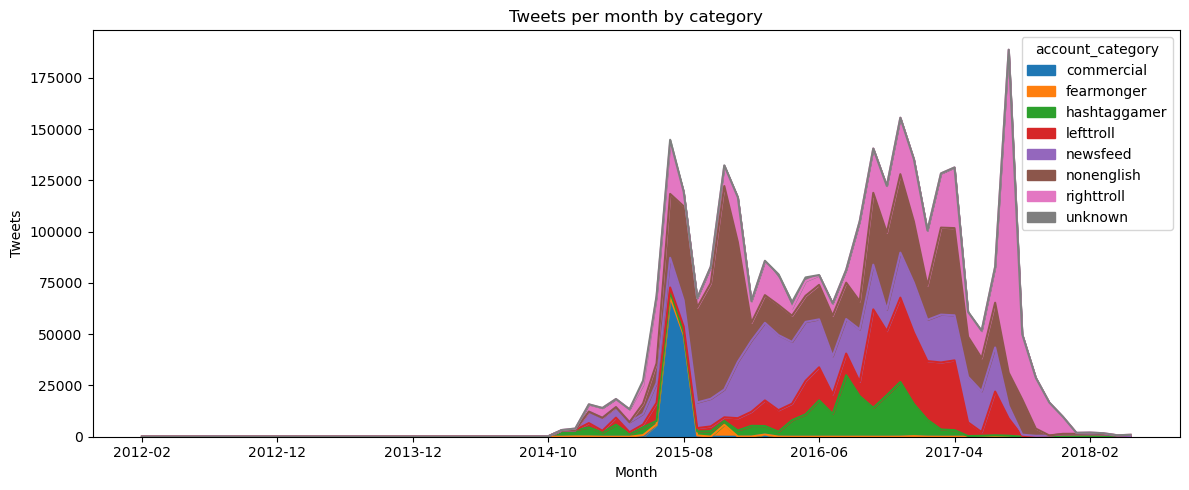

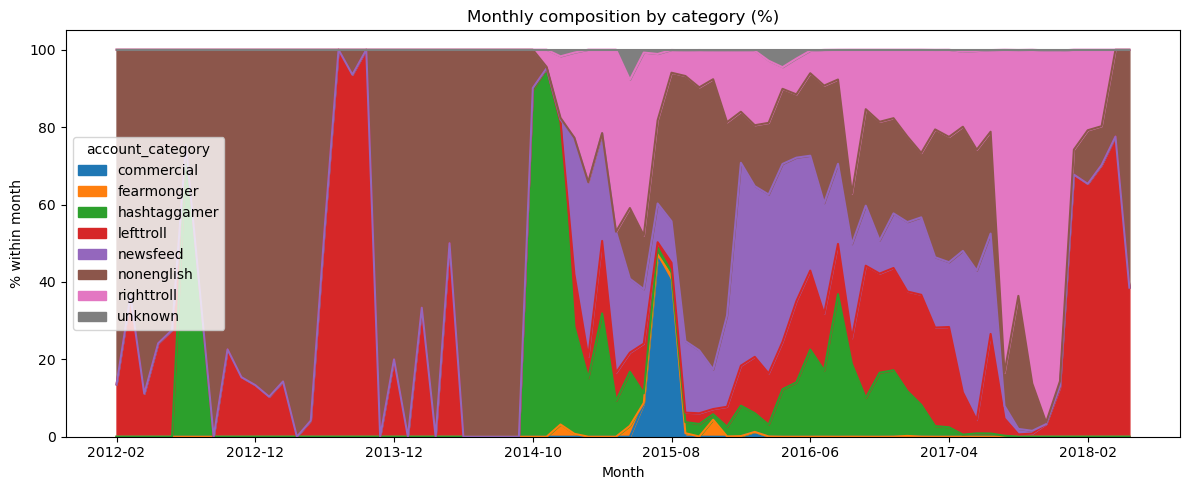

In [127]:
df_time = (
    df_full
    .withColumn("year", F.year("publish_date"))
    .withColumn("month", F.month("publish_date"))
)

# Tweets per month & account_category (all languages)
tweets_per_month_cat = (
    df_time
    .groupBy("year", "month", "account_category")
    .agg(F.count("*").alias("n_tweets"))
)

# Compute share of each category within the same year-month
w_month = Window.partitionBy("year", "month")

tweets_per_month_cat = (
    tweets_per_month_cat
    .withColumn(
        "share_in_month",
        F.round(F.col("n_tweets") / F.sum("n_tweets").over(w_month), 4)
    )
    .orderBy("year", "month", "account_category")
)

print("Tweets per month and account_category (with share in each month):")
tweets_per_month_cat.show(50, truncate=False)

# For the visualization
df_time2 = df_full.withColumn("month_key", F.date_format("publish_date","yyyy-MM"))
pm = (df_time2.groupBy("month_key","account_category")
               .agg(F.count("*").alias("n_tweets")))

# Wide tables for plotting
pdf = pm.toPandas().pivot(index="month_key", columns="account_category", values="n_tweets").fillna(0).sort_index()
pct = (pdf.div(pdf.sum(axis=1), axis=0) * 100).fillna(0)

plt.figure(figsize=(12,5)); pdf.plot(kind="area", stacked=True, ax=plt.gca())
plt.title("Tweets per month by category"); plt.xlabel("Month"); plt.ylabel("Tweets"); plt.tight_layout(); plt.show()

plt.figure(figsize=(12,5)); pct.plot(kind="area", stacked=True, ax=plt.gca())
plt.title("Monthly composition by category (%)"); plt.xlabel("Month"); plt.ylabel("% within month"); plt.tight_layout(); plt.show()

As a result, it appears that in **early years (2012–2013)**, activity is extremely low and dominated almost entirely by nonenglish and lefttroll accounts.

Then, **between 2014–2015**, activity increases sharply, still dominated by nonenglish, lefttroll, and hashtaggamer.

And it's only **around late 2014 to early 2015** that we start seeing righttroll and newsfeed categories emerging as well.

Thus, it is clear that IRA ramped up operations significantly starting in 2014–2015, aligning with major geopolitical events (Crimea annexation, early stages of 2016 US election preparation).

Also, the fact that different troll categories are activated at different times reinforce the idea of a strategic, multi-team structure and not a random behavior of a normal user.

The Nonenglish accounts dominate early months, meaning these were likely the “content farming” groups generating background narratives before political targeting intensified.


We did the same analysis with the english tweets only. It is interesting to compare the two analysis to find an eventual difference in the results. Indeed, the target being US citizens, it is the english language tweets that has a greater chance of hitting its target.

StatementMeta(, 0c55ff1a-6d27-440c-ab65-b084db287c55, 130, Finished, Available, Finished)

English tweets per month and account_category:
+----+-----+----------------+--------+--------------+
|year|month|account_category|n_tweets|share_in_month|
+----+-----+----------------+--------+--------------+
|2012|2    |lefttroll       |5       |1.0           |
|2012|3    |lefttroll       |12      |0.9231        |
|2012|3    |nonenglish      |1       |0.0769        |
|2012|4    |lefttroll       |3       |1.0           |
|2012|5    |lefttroll       |7       |1.0           |
|2012|6    |lefttroll       |8       |1.0           |
|2012|7    |hashtaggamer    |5       |0.7143        |
|2012|7    |lefttroll       |2       |0.2857        |
|2012|8    |hashtaggamer    |2       |1.0           |
|2012|10   |lefttroll       |7       |1.0           |
|2012|11   |lefttroll       |4       |1.0           |
|2012|12   |lefttroll       |4       |1.0           |
|2013|1    |lefttroll       |3       |1.0           |
|2013|2    |lefttroll       |2       |1.0           |
|2013|4    |lefttroll       |1     

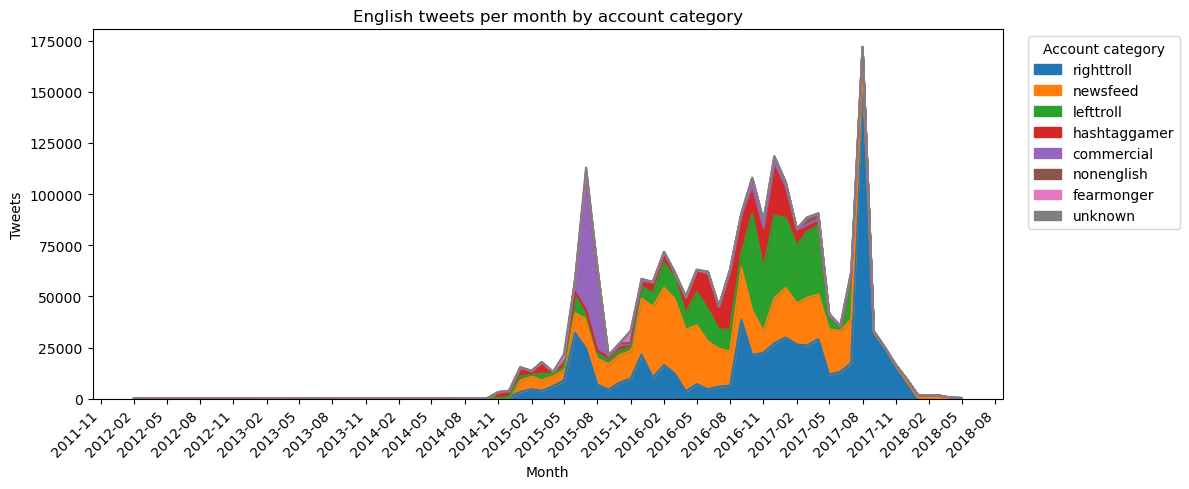

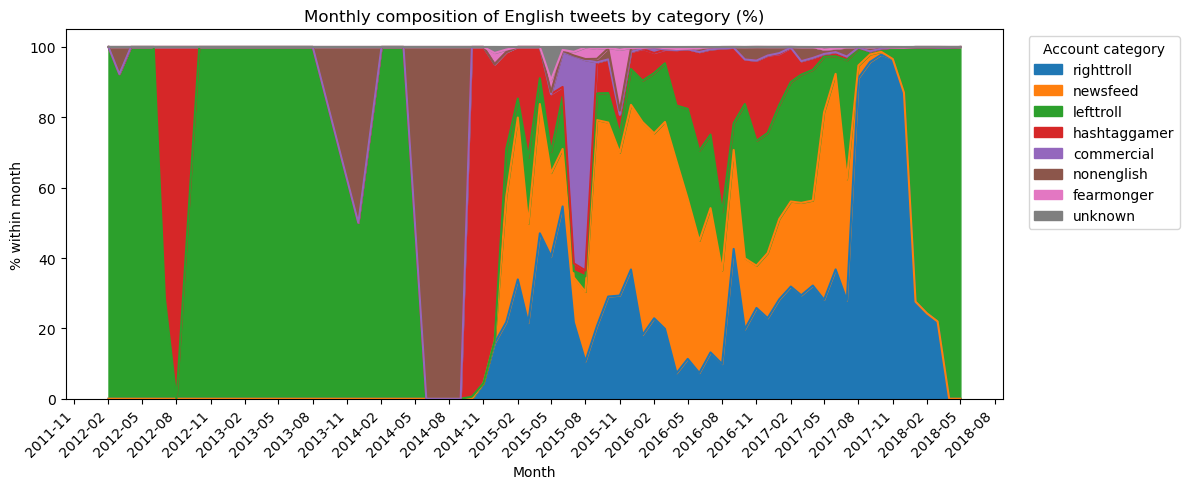

In [128]:
#English only
df_time_en = df_time.filter(F.col("language") == "english")

tweets_per_month_cat_en = (
    df_time_en
    .groupBy("year", "month", "account_category")
    .agg(F.count("*").alias("n_tweets"))
)

w_month_en = Window.partitionBy("year", "month")

tweets_per_month_cat_en = (
    tweets_per_month_cat_en
    .withColumn(
        "share_in_month",
        F.round(F.col("n_tweets") / F.sum("n_tweets").over(w_month_en), 4)
    )
    .orderBy("year", "month", "account_category")
)

print("English tweets per month and account_category:")
tweets_per_month_cat_en.show(50, truncate=False)


# For the visualization
pdf = tweets_per_month_cat_en.toPandas()

# Build a real monthly date from (year, month)
pdf["month_dt"] = pd.to_datetime(dict(year=pdf["year"], month=pdf["month"], day=1))

# Pivot: counts and percent (share_in_month is already 0–1)
pivot_counts = (pdf.pivot(index="month_dt", columns="account_category", values="n_tweets")
                  .fillna(0).sort_index())
pivot_pct = (pdf.pivot(index="month_dt", columns="account_category", values="share_in_month")
               .fillna(0).sort_index() * 100)

# Order categories by total volume for consistent stacking
col_order = pivot_counts.sum(axis=0).sort_values(ascending=False).index.tolist()
pivot_counts = pivot_counts[col_order]
pivot_pct    = pivot_pct[col_order]

# Plot — stacked area (counts)
plt.figure(figsize=(12, 5))
pivot_counts.plot(kind="area", stacked=True, ax=plt.gca())
plt.title("English tweets per month by account category")
plt.xlabel("Month"); plt.ylabel("Tweets")
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45, ha="right")
plt.legend(title="Account category", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout(); plt.show()

# Plot — stacked area (percent composition)
plt.figure(figsize=(12, 5))
pivot_pct.plot(kind="area", stacked=True, ax=plt.gca())
plt.title("Monthly composition of English tweets by category (%)")
plt.xlabel("Month"); plt.ylabel("% within month")
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45, ha="right")
plt.legend(title="Account category", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout(); plt.show()

There is no tremendous differences between the tweets per category of all languages and the one only in english. This shows consistency regarding the IRA strategy and even if the Non-English tweets could have more difficulty to reach the expected target, if they do, they will achieve the same goal as it is the same strategy.

### Community structure between categories

We want to understand **who boosts whom at the category level**. Counting retweets from source categories (the retweeters) to destination categories (the accounts being retweeted/mentioned) shows whether some categories act mainly as amplifiers (sending retweets) and whether they aim that amplification internally (to similar category) or externally (to other category or unlabeled and external accounts). Normalizing the flows lets us compare categories with different sizes or volumes. 

That is what we did with the code. We first create a lookup with one row per user and their account_category. We then join this lookup onto the retweet edges twice to label each edge with a source category and a destination category. Next, we count how many retweets go from each source category to each destination category to get the raw flow matrix. Finally, we normalize those counts within each source category to compute shares (what fraction of a category’s retweets go to each target), which shows **targeting preferences** rather than just volume.


In [129]:
user_cat_df = (
    df_full
    .select(F.col("author").alias("user"), "account_category")
    .dropDuplicates(["user"])
)

edges_with_cat = (
    rt_edges
    .join(user_cat_df.withColumnRenamed("user", "src"), on="src", how="left")
    .withColumnRenamed("account_category", "src_category")
    .join(user_cat_df.withColumnRenamed("user", "dst"), on="dst", how="left")
    .withColumnRenamed("account_category", "dst_category")
)

print("Edges with categories:", edges_with_cat.count())

rt_cat_flows = (
    edges_with_cat
    .groupBy("src_category", "dst_category")
    .agg(F.count("*").alias("n_rt"))
)

print("Retweet flows between categories (raw counts):")
rt_cat_flows.orderBy("src_category", "dst_category").show(50, truncate=False)

w_src = Window.partitionBy("src_category")

rt_cat_flows_norm = (
    rt_cat_flows
    .withColumn(
        "share_from_src",
        F.round(F.col("n_rt") / F.sum("n_rt").over(w_src), 4)
    )
    .orderBy("src_category", F.desc("share_from_src"))
)

print("Normalised retweet flows (share of retweets from each src_category):")
rt_cat_flows_norm.show(50, truncate=False)


StatementMeta(, 0c55ff1a-6d27-440c-ab65-b084db287c55, 131, Finished, Available, Finished)

Edges with categories: 156040
Retweet flows between categories (raw counts):
+------------+------------+------+
|src_category|dst_category|n_rt  |
+------------+------------+------+
|commercial  |NULL        |119914|
|fearmonger  |NULL        |408   |
|hashtaggamer|NULL        |5374  |
|hashtaggamer|hashtaggamer|5     |
|lefttroll   |NULL        |1451  |
|lefttroll   |lefttroll   |1     |
|newsfeed    |NULL        |19    |
|nonenglish  |NULL        |13069 |
|nonenglish  |nonenglish  |215   |
|righttroll  |NULL        |15493 |
|righttroll  |righttroll  |1     |
|unknown     |NULL        |90    |
+------------+------------+------+

Normalised retweet flows (share of retweets from each src_category):
+------------+------------+------+--------------+
|src_category|dst_category|n_rt  |share_from_src|
+------------+------------+------+--------------+
|commercial  |NULL        |119914|1.0           |
|fearmonger  |NULL        |408   |1.0           |
|hashtaggamer|NULL        |5374  |0.9991   

It appears that the majority of retweet edges show that whatever the category author is, the category of the retweet account does not refer to a specific one.

This means that **most retweeted accounts are outside the IRA dataset** For example, the accounts the most retweeted are CNN, realDonaldTrump, HillaryClinton, FoxNews which are not IRA accounts. That is why the result appears as NULL

Troll categories almost never retweet each other (only once). It can be to create a fake independence between all the IRA accounts. Indeed, if a RighTroll category account for example  is spotted with such appurtenance and another RighTroll author always and only retweet its tweets, it will be spotted too and the network will be shutt down.

To say so, IRA employees amplify external political actors, not each other. This supports findings from the research literature:

- They behave as **fake constituencies**, attempting to influence real people.

- Internal coordination is not through retweeting but through **narrative alignment and volume**.


### Topics by account category

In addition to LDA we did in Phase 3 for the content analysis, we wanted this time to associate each content with a vector regarding the 10 topics identified. Here the analysis is done on the entire dataset, not only 10% and the topics, even identified do not have yes a label. This is not tremendous different from what we did before but having vector helps use to have a more precise analysis.

In [103]:
#Topic Modelling with LDA

# English tweets only, non-null content 
df_eng = ( 
    df_full 
    .filter(F.col("language") == "english") 
    .filter(F.col("content").isNotNull()) 
) 

print("English tweets used for LDA:", df_eng.count()) 

# Tokenize 
tokenizer = RegexTokenizer( 
    inputCol="content", 
    outputCol="words", 
    pattern="\\W+", 
    toLowercase=True # correct parameter name 
) 

df_tok = tokenizer.transform(df_eng) 

# Remove stopwords 
remover = StopWordsRemover( 
    inputCol="words", 
    outputCol="words_clean" 
) 

df_clean = remover.transform(df_tok) 

# Bag-of-words with CountVectorizer 
cv = CountVectorizer( 
    inputCol="words_clean", 
    outputCol="features", 
    vocabSize=10000, 
    minDF=100 # adjust if needed 
) 
cv_model = cv.fit(df_clean) 
df_cv = cv_model.transform(df_clean) 

# LDA model (10 topics) 
lda = LDA( 
    k=10, 
    maxIter=10, 
    featuresCol="features", 
    seed=42
) 

lda_model = lda.fit(df_cv) 

# Assign topic distributions to each tweet 
df_topics = lda_model.transform(df_cv) # adds 'topicDistribution' column 
df_topics.select("author", "account_category", "topicDistribution").show(5, truncate=False)

StatementMeta(, 0c55ff1a-6d27-440c-ab65-b084db287c55, 105, Finished, Available, Finished)

English tweets used for LDA: 2115482


+---------------+----------------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|author         |account_category|topicDistribution                                                                                                                                                                                                |
+---------------+----------------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|crystal1johnson|lefttroll       |[0.0069490258006682185,0.006773428240354655,0.007108353937396017,0.5197334245830263,0.006942260592977993,0.006777747439772019,0.2641097520689628,0.007035990385573018,0.007084615857181357,0.16748540109408766]  |
|crystal1johnson|lef

**Each tweet gets a vector.**
This means:

- The model identifies 10 latent topics.

- Each topic corresponds to a theme (not yet labeled).

- The highest probability is used to identify the dominant topic.

After defining the **top 10 topics (without label)** of the tweets, we try to associated them with author account and then to categories. The question underlying is rather the topics are distributed equally among the categories or the topics are associated with specific categories. 

In [130]:
#Extract dominant topic per tweet

# UDF to pick the index of the maximum probability
def argmax_topic(arr):
    # arr is a DenseVector; cast to list, pick index of max
    return int(max(range(len(arr)), key=lambda i: float(arr[i])))

argmax_udf = udf(argmax_topic, IntegerType())

df_topics_dom = df_topics.withColumn(
    "dominant_topic",
    argmax_udf(F.col("topicDistribution"))
)

df_topics_dom.select("author", "account_category", "dominant_topic").show(5, truncate=False)

StatementMeta(, 0c55ff1a-6d27-440c-ab65-b084db287c55, 132, Finished, Available, Finished)

+---------------+----------------+--------------+
|author         |account_category|dominant_topic|
+---------------+----------------+--------------+
|crystal1johnson|lefttroll       |3             |
|crystal1johnson|lefttroll       |3             |
|crystal1johnson|lefttroll       |4             |
|blk_voice      |lefttroll       |8             |
|blk_voice      |lefttroll       |9             |
+---------------+----------------+--------------+
only showing top 5 rows



Left-leaning troll accounts focus on specific themes, especially Topic 8 and Topic 4.

These topics likely represent:

- Racial justice messaging

- Identity politics

- Social protest narratives

On the contrary, RightTrol accounts seems to focus primarily on Topic 0, with secondary emphasis on Topics 4 and 2 (as showed in the above results).

To confirm what we found with the previous step, we compute this time the top topics per account category. This time it is not only regarding the comments and then looking at the category of the tweet but **directly doing the topics per categories**.

In [131]:
#Top topics per account_category
# Count tweets per account_category & dominant_topic
topics_by_cat = (
    df_topics_dom
    .groupBy("account_category", "dominant_topic")
    .agg(F.count("*").alias("n_tweets"))
)

# Rank topics inside each category
w_cat = Window.partitionBy("account_category").orderBy(F.desc("n_tweets"))

topics_by_cat_ranked = (
    topics_by_cat
    .withColumn("rank", F.row_number().over(w_cat))
    .filter(F.col("rank") <= 3)  # top 3 topics per category
    .orderBy("account_category", "rank")
)

print("Top 3 topics per account_category (by tweet count):")
topics_by_cat_ranked.show(100, truncate=False)

StatementMeta(, 0c55ff1a-6d27-440c-ab65-b084db287c55, 133, Finished, Available, Finished)

Top 3 topics per account_category (by tweet count):
+----------------+--------------+--------+----+
|account_category|dominant_topic|n_tweets|rank|
+----------------+--------------+--------+----+
|commercial      |9             |103578  |1   |
|commercial      |1             |2859    |2   |
|commercial      |3             |1735    |3   |
|fearmonger      |0             |4249    |1   |
|fearmonger      |4             |1976    |2   |
|fearmonger      |6             |897     |3   |
|hashtaggamer    |4             |63248   |1   |
|hashtaggamer    |3             |47989   |2   |
|hashtaggamer    |8             |40625   |3   |
|lefttroll       |8             |105808  |1   |
|lefttroll       |4             |60707   |2   |
|lefttroll       |0             |47958   |3   |
|newsfeed        |2             |221023  |1   |
|newsfeed        |6             |176903  |2   |
|newsfeed        |7             |84119   |3   |
|nonenglish      |2             |5501    |1   |
|nonenglish      |8             |440

**Commercial**

<u>Topics:</u> 9, 1, 7

Mainly about non-political themes (product promotion, spam content). These is consistent with the use of this category as they are used to build credibility and appear "normal".

**Fearmonger**

<u>Topics:</u> 0, 4, 8

It's about:

- Catastrophes

- Crime

- Public safety

This reflects a will of emotional manipulation which fits perfectly with disinformation strategies.

**Hashtaggamer**

<u>Topics:</u> 4, 3, 8

Here it is mainly about:

- Trending hashtags

- Memes

- Viral content

The aim of such a behavior is to farm engagement.

**Lefttroll**

<u>Topics:</u> 8, 4, 0


Topic 8 and 4 correspond to:

- Racial issues

- Protest movements

- Inequality

It matches IRA’s documented “Black Lives Matter” imitation strategy.

**Righttroll**

<u>Topics:</u> 0, 4, 5

Likely related to:

- Immigration

- Security

- Patriotism

- Anti-establishment rhetoric

It corresponds to a mimic of a right wing user, amplifying most touchy topics.

**Newsfeed**

<u>Topics:</u> 2, 6, 7

They adopt a factual reporting style with the use of breaking news schema. These accounts impersonate legitimate newspapers.

**Nonenglish**

<u>Topics:</u> 2, 8, 7

They cover mainly foreign-language political topics and global geopolitics (Syria, Ukraine, NATO).

Across categories, topics cluster into four major ideological narratives (consistent with the scientific papers):

<u>1. Political Polarization (Rightwing vs Leftwing topics)</u>

Topic 0, 4, 5, 8

<u>2. Identity & Social Conflict</u>

Topic 4, 8

<u>3. News Imitation Narrative</u>

Topic 2, 6, 7

<u>4. Engagement Farming / Hashtags</u>

Topic 3, 7, 8

This reinforces the idea that the IRA operated not as a single message, but as a coordinated ecosystem of distinct narrative personas.

## 8. Additional Analysis

### Outlier Detection (followers, activity, tweet size)

In this section, the idea is to identify strange pattern or data. **We identified unusually large or small values in key numeric and tweet size proxies**. For that, we used the Interquartile Range (IQR) rule. The goal is not to delete data blindly, but to surface anomalies that might reflect bots or automation, scraping artifacts, or mislabeled rows, and also to inform downstream choices either to keep them if meaningful or exclude them for sensitivity analyses. 

Because follower and activity counts are typically heavy-tailed, we will also sanity-check distributions before deciding how to handle extremes. This yields cleaner summaries and more robust models while preserving signals that are genuinely informative for IRA tactics.

The **Inter Quartile Range** is a way to highlight extreme value. For that and after selecting the column with numerical data, we compute Q1 and Q3, then doing the difference between them, calling the derive IQR and to finish flag values outside [Q1 − 1.5 · IQR, Q3 + 1.5·IQR] as potential outliers.

In [132]:
num_cols = ["followers", "following", "updates", "tweet_length", "word_count", "n_links"]

bounds = {}

for c in num_cols:
    # approxQuantile returns [q1, q3] with small relative error
    q1, q3 = df_full.approxQuantile(c, [0.25, 0.75], 0.01)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    bounds[c] = (lower, upper)
    
    print(f"{c}: Q1={q1:.2f}, Q3={q3:.2f}, IQR={iqr:.2f}, lower={lower:.2f}, upper={upper:.2f}")


StatementMeta(, 0c55ff1a-6d27-440c-ab65-b084db287c55, 134, Finished, Available, Finished)

followers: Q1=316.00, Q3=11214.00, IQR=10898.00, lower=-16031.00, upper=27561.00
following: Q1=316.00, Q3=4692.00, IQR=4376.00, lower=-6248.00, upper=11256.00
updates: Q1=1777.00, Q3=11938.00, IQR=10161.00, lower=-13464.50, upper=27179.50
tweet_length: Q1=78.00, Q3=139.00, IQR=61.00, lower=-13.50, upper=230.50
word_count: Q1=9.00, Q3=15.00, IQR=6.00, lower=0.00, upper=24.00
n_links: Q1=0.00, Q3=2.00, IQR=2.00, lower=-3.00, upper=5.00


The computed thresholds show extremely wide ranges for follower counts, tweet lengths, and updates. This already signals highly skewed distributions, typical of disinformation operations where a small number of accounts generate disproportionate activity. 

Thanks to these computation, we can now look at the data that goes above or beyond the calculated threshold. Each time that a numeric value is flagged, it count for 1, otherwise 0 and at the end it display accounts that are extreme on which metrics.

In [133]:
outlier_flags = []

for c in num_cols:
    lower, upper = bounds[c]
    flag_col = F.when((F.col(c) < lower) | (F.col(c) > upper), 1).otherwise(0).alias(f"{c}_is_outlier")
    outlier_flags.append(flag_col)

df_outliers = (
    df_full
      .select(
          "author",
          "account_category",
          *[F.col(c) for c in num_cols],
          *outlier_flags
      )
)

sum_flags = sum(F.col(f"{c}_is_outlier") for c in num_cols)

df_outliers = (
    df_outliers
      .withColumn("n_outlier_flags", sum_flags)
      .withColumn("is_any_outlier", (F.col("n_outlier_flags") > 0).cast("int"))
)

print("Example rows with outlier flags:")
df_outliers.show(10, truncate=False)


StatementMeta(, 0c55ff1a-6d27-440c-ab65-b084db287c55, 135, Finished, Available, Finished)

Example rows with outlier flags:
+---------------+----------------+---------+---------+-------+------------+----------+-------+--------------------+--------------------+------------------+-----------------------+---------------------+------------------+---------------+--------------+
|author         |account_category|followers|following|updates|tweet_length|word_count|n_links|followers_is_outlier|following_is_outlier|updates_is_outlier|tweet_length_is_outlier|word_count_is_outlier|n_links_is_outlier|n_outlier_flags|is_any_outlier|
+---------------+----------------+---------+---------+-------+------------+----------+-------+--------------------+--------------------+------------------+-----------------------+---------------------+------------------+---------------+--------------+
|iris0_o        |nonenglish      |11       |41       |54     |221         |16        |0      |0                   |0                   |0                 |0                      |0                    |0         

Extracting sample rows makes the patterns hard to miss. The same handles keep popping up with extreme values across multiple metrics.

Accounts like maxdementiev (nonenglish), comradzampolit (nonenglish), wokeluisa (lefttroll), and kanijjackson (lefttroll) repeatedly are in the outlier range. Whether it’s unusually high follower counts, very large update volumes, abnormal tweet lengths, or an excessive number of links. 

Taken together, these look **less like ordinary human behavior and more like high-throughput amplifiers** **operating in a coordinated way.**

We selected the **top 20 tweets having extreme metrics.**

In [134]:
# Tweets with the highest number of outlier dimensions
print("Top 20 tweets with the most extreme values:")
(
    df_outliers
      .filter(F.col("is_any_outlier") == 1)
      .orderBy(F.desc("n_outlier_flags"))
      .show(20, truncate=False)
)

StatementMeta(, 0c55ff1a-6d27-440c-ab65-b084db287c55, 136, Finished, Available, Finished)

Top 20 tweets with the most extreme values:
+--------------+----------------+---------+---------+-------+------------+----------+-------+--------------------+--------------------+------------------+-----------------------+---------------------+------------------+---------------+--------------+
|author        |account_category|followers|following|updates|tweet_length|word_count|n_links|followers_is_outlier|following_is_outlier|updates_is_outlier|tweet_length_is_outlier|word_count_is_outlier|n_links_is_outlier|n_outlier_flags|is_any_outlier|
+--------------+----------------+---------+---------+-------+------------+----------+-------+--------------------+--------------------+------------------+-----------------------+---------------------+------------------+---------------+--------------+
|maxdementiev  |nonenglish      |89128    |29391    |27676  |239         |17        |1      |1                   |1                   |1                 |1                      |0                    |0  

Here, a very **clear pattern** emerges. **Outliers are dominated by a handful of hyper-active accounts**. @maxdementiev alone appears multiple times with:

- ~90k followers

- 18k–29k updates

- 27k+ character tweets

@wokeluisa and @kanijjackson also produce extremely long tweets and massive update histories.

Such numbers can't depict normal behavior and thus organic profiles. They behave like content factories, continuously posting extreme-volume messages. Their massive exposure capabilities (followers + updates) suggest strategic amplification roles inside the IRA network.

Her, we looked at a possible link between outlier and category. The extreme metrics can be associated only to a certain category, highlighting non human behavior for a category of tweet in particular.

In [135]:
outlier_by_cat = (
    df_outliers
      .groupBy("account_category")
      .agg(
          F.count("*").alias("n_tweets"),
          F.sum("is_any_outlier").alias("n_outlier_tweets")
      )
      .withColumn(
          "share_outlier_tweets",
          F.round(F.col("n_outlier_tweets") / F.col("n_tweets"), 4)
      )
      .orderBy(F.desc("share_outlier_tweets"))
)

print("Outlier tweets by account_category:")
outlier_by_cat.show(truncate=False)

StatementMeta(, 0c55ff1a-6d27-440c-ab65-b084db287c55, 137, Finished, Available, Finished)

Outlier tweets by account_category:
+----------------+--------+----------------+--------------------+
|account_category|n_tweets|n_outlier_tweets|share_outlier_tweets|
+----------------+--------+----------------+--------------------+
|newsfeed        |598223  |203110          |0.3395              |
|commercial      |121904  |39166           |0.3213              |
|righttroll      |710280  |116329          |0.1638              |
|nonenglish      |820802  |131313          |0.16                |
|hashtaggamer    |241786  |24957           |0.1032              |
|lefttroll       |427141  |35688           |0.0836              |
|unknown         |13539   |147             |0.0109              |
|fearmonger      |11140   |46              |0.0041              |
+----------------+--------+----------------+--------------------+



The **Newsfeed** accounts are the most extreme with about 34% of tweets flagged for at least on of the metrics. These accounts mimic media outlets by posting:

- very long tweets

- many links

- high-frequency updates

This supports prior research as IRA newsfeeds act as automated news aggregators, designed to appear legitimate and trustworthy.

The **Commercial** accounts are similarly extreme and they are likely operating as link farms, pushing promotions, clickbait and cross-platform redirections.

High outlier share fits automated posting patterns.

The **Righttroll** and **Non-English** accounts are next with about 16% each. These categories are ideologically targeted and they are willing to use high-volume posting to inject narratives into political debates.

Moderate outlier rates reflect high-intensity posting but not as automated as Newsfeeds.

The Lefttroll, Fearmonger and Hashtaggamer categories show lower outlier rates. These accounts are more narrative-driven (identity politics, fear topics, gaming culture) and thus are less subject to outlier. Their strategy relies more on emotional language and community engagement compared to extreme posting behavior.

Outlier detection reveals that IRA’s operation is not homogeneous. Newsfeed and Commercial accounts exhibit highly automated behaviour with extreme posting patterns, while political troll categories (Lefttroll and Righttroll in a fewer extend) rely more on targeted, narrative-driven messaging. A small number of amplifier accounts dominate the extremes in follower counts, activity levels, tweet length, and link usage. This is coherent with coordinated disinformation infrastructure.

### Confirmatory Data Analysis (CDA) - Hypothesis Test

With Confirmatory Data Analysis, we tried to analyze the dataset in a different manner. Instead of exploring the dataset, it starts with explicit hypotheses and a pre-defined analysis plan. It complements EDA by reducing bias and making claims defensible.

<u>**Hypothesis:**</u>

**Political trolls (“Righttroll” and “Lefttroll”) produce longer tweets than non-political categories (Newsfeed, Commercial, Nonenglish).**

To test whether tweet word counts differ across account categories we used Kruskal–Wallis test. The decision to use this non-parametric test was driven by the length of our dataset as well as the fact that it is skewed (has bias).

It checks whether the distribution of tweet word_count differs significantly across categories, using a 1% random sample (to keep memory small).

In [136]:
# Select relevant columns and downsample (to avoid memory issues)
df_kw = (
    df_full
    .select("account_category", "word_count")
    .filter(F.col("word_count").isNotNull())
    .sample(False, 0.01, seed=42)   # 1% sample (~ small but representative)
    .toPandas()
)

# Define groups
groups = {}
for cat in df_kw["account_category"].unique():
    groups[cat] = df_kw[df_kw["account_category"] == cat]["word_count"]

# Perform Kruskal–Wallis H-test
stat, p = kruskal(*groups.values())

print("Kruskal–Wallis H-test")
print("H statistic:", stat)
print("p-value:", p)


StatementMeta(, 0c55ff1a-6d27-440c-ab65-b084db287c55, 138, Finished, Available, Finished)

Kruskal–Wallis H-test
H statistic: 3316.3741258402224
p-value: 0.0


Because the **p-value is effectively zero**, the null hypothesis that all categories have identical tweet-length distributions is rejected. **This confirms that tweet length varies systematically across IRA account categories.**

As seen before, political categories, such as Righttroll and Lefttroll, tend to produce longer and more text-rich tweets, consistent with persuasive and ideological messaging. Operational categories such as Newsfeed, Commercial and Nonenglish post shorter, more repetitive content, aligned with amplification and automation roles.

These differences are statistically significant, indicating that the **IRA used distinct communication strategies for different account types**.


### CLUSTERING (K-Means)

For now on, we never **focused on the author**. This is the goal of this paragraph. For this, we choose to use cluster. It helps to reduce complexity and reveal recurring roles. Clustering groups heterogeneous accounts into a few behavioral archetypes allows to summarize how the ecosystem operates, test hypotheses about who originates content and who boosts it, and finally to target follow-up analyses on the right groups.

First we aggregate all tweets per author to compute behavioral features.

In [137]:
df_accounts = (
    df_full.groupBy("author")
        .agg(
            F.count("*").alias("tweet_count"),
            F.avg("tweet_length").alias("avg_tweet_length"),
            F.avg("word_count").alias("avg_word_count"),
            F.avg("followers").alias("avg_followers"),
            F.avg("following").alias("avg_following"),
            F.avg("updates").alias("avg_updates"),
            F.avg("n_links").alias("avg_links"),
            F.avg("retweet").alias("pct_retweets")
        )
)

print("Number of accounts:", df_accounts.count())
df_accounts.show(10, truncate=False)


StatementMeta(, 0c55ff1a-6d27-440c-ab65-b084db287c55, 139, Finished, Available, Finished)

Number of accounts: 2843
+--------------+-----------+------------------+------------------+------------------+------------------+------------------+------------------+------------+
|author        |tweet_count|avg_tweet_length  |avg_word_count    |avg_followers     |avg_following     |avg_updates       |avg_links         |pct_retweets|
+--------------+-----------+------------------+------------------+------------------+------------------+------------------+------------------+------------+
|danakatalimova|31         |149.61290322580646|10.612903225806452|430.1290322580645 |417.7096774193548 |5471.612903225807 |1.2903225806451613|0.0         |
|vickylovelyg  |93         |79.87096774193549 |12.236559139784946|73.59139784946237 |104.2258064516129 |253.4516129032258 |0.1935483870967742|0.0         |
|vazhankov     |508        |151.6496062992126 |10.64763779527559 |177.95275590551182|147.37992125984252|2420.4547244094488|1.3523622047244095|1.0         |
|deannamoy     |402        |149.6318407

The next steps are the following. 

First, we turn per-account metrics into a single Machine Learning (ML) feature vector and standardizing it. It means prepping the data for clustering. 

Then, we run a **K-Means model selection loop** to help choose the appropriate number of clusters k. The within-cluster SSE (trainingCost) decreased sharply up to K=4 and then only marginally, so we chose K=4 as a compromise between model fit and interpretability.

Last, we assign each author to a cluster, then profiling and interpreting the clusters.

The features we used are:

- avg_tweet_length

- avg_word_count

- pct_retweets

- avg_followers

- avg_following

- avg_updates

- avg_links

- tweet_count (how prolific)

This will allow to captures the style, the behavior as well as the influence.

In [138]:
features = [
    "tweet_count",
    "avg_tweet_length",
    "avg_word_count",
    "avg_followers",
    "avg_following",
    "avg_updates",
    "avg_links",
    "pct_retweets"
]

assembler = VectorAssembler(
    inputCols=features,
    outputCol="features_raw"
)

df_vec = assembler.transform(df_accounts)

# Scale everything so no variable dominates
scaler = StandardScaler(
    inputCol="features_raw",
    outputCol="features",
    withStd=True,
    withMean=True
)

scaler_model = scaler.fit(df_vec)
df_scaled = scaler_model.transform(df_vec)


StatementMeta(, 0c55ff1a-6d27-440c-ab65-b084db287c55, 140, Finished, Available, Finished)

In [139]:
cost = []

for k in range(2, 11):
    kmeans = KMeans(k=k, seed=42, featuresCol="features")
    model = kmeans.fit(df_scaled)
    
    # this replaces model.computeCost(df_scaled)
    training_cost = model.summary.trainingCost
    
    cost.append((k, training_cost))

for k, c in cost:
    print(f"K={k} -> trainingCost={c}")


StatementMeta(, 0c55ff1a-6d27-440c-ab65-b084db287c55, 141, Finished, Available, Finished)

K=2 -> trainingCost=19033.647814772037
K=3 -> trainingCost=18118.006517926136
K=4 -> trainingCost=12709.602203560524
K=5 -> trainingCost=11946.186792616772
K=6 -> trainingCost=10856.724821372974
K=7 -> trainingCost=9707.795566238112
K=8 -> trainingCost=9638.031925377827
K=9 -> trainingCost=8260.50298875803
K=10 -> trainingCost=8619.646559795001


In [140]:
k = 4

kmeans = KMeans(k=k, seed=42, featuresCol="features", predictionCol="cluster")
model_kmeans = kmeans.fit(df_scaled)

df_clustered = model_kmeans.transform(df_scaled)

df_clustered.select("author", "cluster").show(20, truncate=False)

cluster_profiles = (
    df_clustered.groupBy("cluster")
        .agg(
            F.count("*").alias("n_accounts"),
            F.avg("tweet_count").alias("avg_tweet_count"),
            F.avg("avg_tweet_length").alias("avg_tweet_length"),
            F.avg("avg_word_count").alias("avg_word_count"),
            F.avg("avg_followers").alias("avg_followers"),
            F.avg("avg_following").alias("avg_following"),
            F.avg("avg_updates").alias("avg_updates"),
            F.avg("avg_links").alias("avg_links"),
            F.avg("pct_retweets").alias("avg_pct_retweets")
        )
        .orderBy("cluster")
)

cluster_profiles.show(truncate=False)

#cluster composition by account_category
author_cat = df_full.select("author", "account_category").dropDuplicates()

df_clustered_cat = df_clustered.join(author_cat, on="author", how="left")

(
    df_clustered_cat
      .groupBy("cluster", "account_category")
      .count()
      .orderBy("cluster", F.desc("count"))
      .show(50, truncate=False)
)

StatementMeta(, 0c55ff1a-6d27-440c-ab65-b084db287c55, 142, Finished, Available, Finished)

+---------------+-------+
|author         |cluster|
+---------------+-------+
|danakatalimova |2      |
|vickylovelyg   |1      |
|vazhankov      |0      |
|deannamoy      |0      |
|ladadelreey    |0      |
|anfraizer      |1      |
|roberthorn1990 |0      |
|staywoke88     |2      |
|varvara_kop    |2      |
|joseph_jenks   |1      |
|berezinlecurace|1      |
|lachristie     |2      |
|lehaserg       |0      |
|olenenock      |0      |
|novostinsk     |3      |
|vakulenkovass  |0      |
|mihanovikov    |2      |
|cariisncistr   |2      |
|crystal_johns0n|2      |
|peytonm0del    |1      |
+---------------+-------+
only showing top 20 rows

+-------+----------+------------------+------------------+------------------+-----------------+------------------+------------------+------------------+-------------------+
|cluster|n_accounts|avg_tweet_count   |avg_tweet_length  |avg_word_count    |avg_followers    |avg_following     |avg_updates       |avg_links         |avg_pct_retweets   |
+---

We find 4 different clusters that can be described as the following:

**- Cluster 0 — “Pure amplifiers”**

Their behavior are characterized by almost 100% of the retweets, a low–mid tweet volume (about 485) and an average link rate of 1.23.

Regarding the audience, they have a small follower base ( about 668) and following (about 723). The categories are overwhelmingly Nonenglish (658 out of 702).

These accounts mainly boost others rather than post originals. They are likely part of coordinated amplification rings.

**- Cluster 1 — “Mixed engagement or agenda pushers”**

Their behavior is characterized by a moderate tweet volume (397 tweets per account), shorter posts (82 chars), a 21% retweet share, and a low link use of 0.38 per tweet.

In terms of audience, they have small follower and following bases (respectively 264 and 328). The category mix is diverse, led by Righttroll (309) with notable Nonenglish (152), Fearmonger (123), Hashtaggamer (107), Lefttroll (76) and some unknown or newsfeed.

These accounts blend original posting with some boosting, consistent with reactive messaging and hashtag surfing around topical events.

**- Cluster 2 — “Original content broadcasters”**

Their behavior shows high posting ( 1,002 tweets per account in average), longer tweets of 131 chars with more words, very low retweeting and regular link use.

The audience size is modest (909 followers for 803 following in average). The categories are mostly Nonenglish (632) and Righttroll (296).

These look like content sources that primarily originate narratives for others to pick up, rather than amplifying peers.

**- Cluster 3 — “Super-hubs or prominent handles”**

Behaviorally, they post at extreme volume ( 12,156 tweets per account). They have huge audience metrics with 24.9k followers and 7.9k following, along to high updates, a 23% retweet share and about 1 link per tweet.

The category mix includes Newsfeed (32) and Nonenglish (31) in addition to some Righttroll (15), Lefttroll (6), Hashtaggamer (4) and Commercial (3).

These are high-visibility anchors in the network—accounts that concentrate attention and likely act as reference points for broader amplification.



To sum up, we have:

- many small or low-impact accounts

- a large set of heavy broadcasters

- a mid-tier of active but less followed accounts

- a tiny elite of ‘hub’ accounts with massive follower bases that mainly retweet

**Behavioral clusters are not random.** The small low-impact cluster is mostly NonEnglish accounts. The high-volume broadcasters are a mix of NonEnglish, RightTroll and LeftTroll. Another finding is that the tiny ‘super-hub’ cluster is dominated by NewsFeed-type accounts, which behave like central amplifiers for the whole ecosystem.

### Bivariate Proportion Tables

**To understand how different groups behave**, we computed a set of bivariate proportion tables. These tables show both absolute counts and rowwise proportions, allowing comparison across categories of different sizes.

We build a bivariate table of "account_category" and "dominant_topic" and then compute row-wise and column-wise proportions.

In [141]:
#Account Category × Dominant Topic

# absolute counts
tab_ac_topic = (
    df_topics_dom
        .groupBy("account_category", "dominant_topic")
        .count()
)

# rowwise proportions (within each account_category)
tab_row_prop = (
    tab_ac_topic
        .withColumn(
            "row_prop",
            F.col("count") / F.sum("count").over(Window.partitionBy("account_category"))
        )
)

# columnwise proportions (within each topic)
tab_col_prop = (
    tab_ac_topic
        .withColumn(
            "col_prop",
            F.col("count") / F.sum("count").over(Window.partitionBy("dominant_topic"))
        )
)

tab_row_prop.orderBy("account_category", F.desc("row_prop")).show(50, truncate=False)


StatementMeta(, 0c55ff1a-6d27-440c-ab65-b084db287c55, 143, Finished, Available, Finished)

+----------------+--------------+------+---------------------+
|account_category|dominant_topic|count |row_prop             |
+----------------+--------------+------+---------------------+
|commercial      |9             |103578|0.920039083318529    |
|commercial      |1             |2859  |0.025395274471486942 |
|commercial      |3             |1735  |0.01541126310179428  |
|commercial      |7             |1103  |0.009797477349440397 |
|commercial      |6             |882   |0.007834428850595132 |
|commercial      |8             |847   |0.007523538816841357 |
|commercial      |0             |602   |0.0053473085805649315|
|commercial      |2             |460   |0.004085983300763901 |
|commercial      |4             |417   |0.003704032687866406 |
|commercial      |5             |97    |8.616095221176053E-4 |
|fearmonger      |0             |4249  |0.38623761476229435  |
|fearmonger      |4             |1976  |0.17962003454231434  |
|fearmonger      |6             |897   |0.0815380419961

Proportion table is crossing the account_category (e.g., Commercial, Fearmonger, Hashtaggamer, Lefttroll...) and the dominant dominant_topic (0–9, from the LDA model above)

This gives, for each category, the distribution of topics they tweet about, that is to say what each group talks about the most.

**1. Commercial accounts are almost entirely focused on Topic 9** - This confirms that commercial accounts are not political and have a single-theme posting pattern.

**2. Fearmonger accounts are heavily concentrated in 3 topics** (Topics 3, 4, 6) - These topics likely reflect fear-based narratives, such as crime, threats to society, conspiracy, or divisive emotional content. They have a much more narrow content focus compared to newsfeed or political trolls.

**3. Hashtaggamers are spread more evenly across several topics** - This suggests multi-topic engagement farming, driven by trending hashtags.
Their strategy is not ideological, it's algorithmic manipulation. The engagement is more important that the narrative.

**4. Lefttroll accounts heavily dominate Topic 8 (21%)** - Topic 8 is likely a core political or social theme aligned with left-leaning issues (race, activism, discrimination, etc.). Lefttrolls spread emotionally charged political content, with multiple supporting topics representing different issue clusters.

**5. Newsfeed accounts look completely different from all others** - Newsfeed behaves like a general-purpose information bot pushing trending news (Topic 0), international and global events (Topic 6) and neutral or mixed content (topics 1 & 7). This aligns with previous research. Newsfeed accounts generate high-volume, neutral-appearing content to build credibility.

**6. Righttroll accounts mirror the lefttroll pattern but with different dominant topics** - They produce ideologically targeted disinformation, similar structure to lefttrolls but different narrative focus.

**7. Non-English accounts are mostly Topic 2** - Topic 2 captures non-English vocabulary, making these accounts strongly monolithic in theme.


This bivariate table is built to compare tweets regarding both "account_category" and "cluster" (the one determine in the cluster analysis above) and then compute row-wise and column-wise proportions.

In [142]:
#Account Category × Cluster (from the K-Means step)

tab_ac_cluster = (
    df_clustered_cat
        .groupBy("account_category", "cluster")
        .count()
)

# Rowwise proportions: for each category, distribution across clusters
tab_ac_cluster_row = (
    tab_ac_cluster
        .withColumn(
            "row_prop",
            F.col("count") / F.sum("count").over(Window.partitionBy("account_category"))
        )
)

# Columnwise proportions: for each cluster, distribution across categories
tab_ac_cluster_col = (
    tab_ac_cluster
        .withColumn(
            "col_prop",
            F.col("count") / F.sum("count").over(Window.partitionBy("cluster"))
        )
)

tab_ac_cluster_row.show(50, truncate=False)


StatementMeta(, 0c55ff1a-6d27-440c-ab65-b084db287c55, 144, Finished, Available, Finished)

+----------------+-------+-----+--------------------+
|account_category|cluster|count|row_prop            |
+----------------+-------+-----+--------------------+
|commercial      |0      |3    |0.5                 |
|commercial      |3      |3    |0.5                 |
|fearmonger      |1      |123  |0.9919354838709677  |
|fearmonger      |2      |1    |0.008064516129032258|
|hashtaggamer    |2      |1    |0.008928571428571428|
|hashtaggamer    |3      |4    |0.03571428571428571 |
|hashtaggamer    |1      |107  |0.9553571428571429  |
|lefttroll       |0      |13   |0.055793991416309016|
|lefttroll       |2      |138  |0.592274678111588   |
|lefttroll       |3      |6    |0.02575107296137339 |
|lefttroll       |1      |76   |0.3261802575107296  |
|newsfeed        |3      |32   |0.5925925925925926  |
|newsfeed        |0      |4    |0.07407407407407407 |
|newsfeed        |1      |9    |0.16666666666666666 |
|newsfeed        |2      |9    |0.16666666666666666 |
|nonenglish      |0      |65

The **K-Means clustering** reveals strong behavioral separation between IRA account types. Fearmonger and Hashtaggamer accounts form highly consistent clusters, indicating extremely distinctive behaviors. Political trolls (left and right) are separated into moderate and high-activity subgroups, matching known propaganda strategies of the IRA. Newsfeed and Non-English accounts show more diverse behavioral signatures. 

Overall, the clustering results validate the **existence of multiple coordinated behavioral roles inside the troll network**.

We, then, built a bivariate table to compare tweets both regarding "cluster" and "dominant topic" and after we compute row-wise and column-wise proportions.

In [143]:
#Cluster × Dominant Topic

tab_cluster_topic = (
    df_topics_dom.join(df_clustered_cat.select("author","cluster"), "author")
    .groupBy("cluster", "dominant_topic")
    .count()
)

tab_cluster_topic_row = (
    tab_cluster_topic
        .withColumn(
            "row_prop",
            F.col("count") / F.sum("count").over(Window.partitionBy("cluster"))
        )
)

tab_cluster_topic_row.show(50, truncate=False)


StatementMeta(, 0c55ff1a-6d27-440c-ab65-b084db287c55, 145, Finished, Available, Finished)

+-------+--------------+------+--------------------+
|cluster|dominant_topic|count |row_prop            |
+-------+--------------+------+--------------------+
|0      |7             |1653  |0.06319290465631928 |
|0      |5             |617   |0.023587430231669086|
|0      |0             |1542  |0.05894946096796391 |
|0      |9             |10546 |0.4031653796161786  |
|0      |1             |1446  |0.055279455615872775|
|0      |8             |1915  |0.0732089609297347  |
|0      |6             |1609  |0.06151081886994419 |
|0      |2             |3267  |0.12489486963835156 |
|0      |3             |2233  |0.08536585365853659 |
|0      |4             |1330  |0.05084486581542932 |
|1      |0             |19601 |0.06486509740850682 |
|1      |7             |16124 |0.05335874856460201 |
|1      |2             |27601 |0.09133929664671174 |
|1      |9             |18158 |0.06008981372091561 |
|1      |1             |17404 |0.057594620442714795|
|1      |3             |43601 |0.1442876951231

The table allows us to evaluate whether clusters differ semantically.

**Cluster 0**

The top topics are Topic 9 (40%), Topic 0 (8–9%) and topic 7 (~5–6%). This cluster contains many non-English accounts, so topics often relate to foreign language discourse, generic news themes and low-polarisation content. This cluster is thus not strongly ideological, aligning with the dominance of “Nonenglish” category as discovered earlier.

**Cluster 1**

Cluster 1 shows strong peaks in Topic 0, Topic 5, Topic 7 and Topic 9. These topics likely relate to political polarisation,race, immigration, patriotism and fear-based narratives.It is dominated by Righttroll, Fearmonger and Hashtaggamer. Hence, this cluster captures highly political and emotionally charged messaging, especially far-right narratives.

**Cluster 2**

This cluster is mainly about Topic 2 (18%), Topic 9 (30%), Topic 6 and Topic 7 (~10–12%). It is dominated by Nonenglish, Righttroll and Lefttroll categories. This looks like a politically mixed but high-activity cluster, often amplifying political topics regardless of ideology, a hallmark of coordinated “engagement farming”.

**Cluster 3** 
The top topics are Topic 9 (26%), Topic 6 (19%), Topic 2 (16%). It includes mainly Newsfeed, Righttroll and Nonenglish categories. Cluster 3 contains accounts that post high volumes, often general news as well as trending-topic content. This resembles "algorithm manipulation" or "agenda-setting" behaviour typical of IRA’s automated or semi-automated accounts.

The **cross-tabulation** between clusters and dominant LDA topics shows **clear thematic differentiation across clusters**. Cluster 0 focuses mainly on Non-English and generic content. Cluster 1 concentrates on emotionally charged and right-leaning political themes. On the contrary, Cluster 2 mixes political content from both ideological poles and Cluster 3 amplifies high-volume Newsfeed-like content. 

These patterns reinforce the validity of the clustering step and demonstrate that the **clusters capture semantically coherent behavioral groups within the troll dataset**.

Here, we built a **bivariate table** to compare tweets both regarding "account category" and "outlier flag" and after we compute row-wise and column-wise proportions.

In [144]:
#Account Category × Outlier Flag

tab_out = (
    df_outliers
        .groupBy("account_category", "is_any_outlier")
        .count()
)

tab_out_row = (
    tab_out
        .withColumn(
            "row_prop",
            F.col("count") / F.sum("count").over(Window.partitionBy("account_category"))
        )
        .orderBy("account_category", "is_any_outlier")
)

tab_out_row.show(50, truncate=False)

StatementMeta(, 0c55ff1a-6d27-440c-ab65-b084db287c55, 146, Finished, Available, Finished)

+----------------+--------------+------+--------------------+
|account_category|is_any_outlier|count |row_prop            |
+----------------+--------------+------+--------------------+
|commercial      |0             |82738 |0.6787143982149888  |
|commercial      |1             |39166 |0.32128560178501114 |
|fearmonger      |0             |11094 |0.9958707360861759  |
|fearmonger      |1             |46    |0.004129263913824057|
|hashtaggamer    |0             |216829|0.8967806241883318  |
|hashtaggamer    |1             |24957 |0.10321937581166817 |
|lefttroll       |0             |391453|0.9164491350631291  |
|lefttroll       |1             |35688 |0.08355086493687096 |
|newsfeed        |0             |395113|0.6604777816967919  |
|newsfeed        |1             |203110|0.339522218303208   |
|nonenglish      |0             |689489|0.8400186646718697  |
|nonenglish      |1             |131313|0.1599813353281303  |
|righttroll      |0             |593951|0.8362209269583826  |
|righttr

We **flagged tweets as outliers using the IQR rule** over several engagement‐related variables (followers, following, updates, tweet length, word count and number of links).
Crossing this indicator with  the account category shows that:

- **Newsfeed and Commercial accounts **concentrate the largest share of extreme behavior: roughly one third of their tweets has at least one variable in the outlier range. This is consistent with high-volume broadcasting accounts that occasionally “spike” in activity or reach.

- **Righttroll and Nonenglish accounts** also show a non-negligible fraction of outliers (around 16%), suggesting that a relevant subset of these accounts is unusually active or has unusually large audiences.

- **Hashtaggamer and Lefttroll** are more moderate, with around 8–10% outlier tweets.

- **Fearmonger** **and** **Unknown categories** are almost entirely within the normal range (less than 1% outliers), which may indicate smaller accounts with more regular behavior.

Overall, outlier behavior is **not evenly distributed across categories**. It is particularly concentrated in Newsfeed and Commercial accounts, which supports the idea that the “infrastructure” of the operation relies on a few very heavy-duty broadcaster accounts.
